# Aggregated Flare Timing Analysis — All Seeds × Folds

**Prerequisites**

1. Train and evaluate all seeds and folds with `scripts/train_kfold_multiseed.py`.
2. Merge the per-seed outputs with `python -m flare_forecast.analysis.merge_results`. This produces the merged predictions and metrics CSVs (`results/kfold_all_seeds_predictions_<tag>.csv` and `results/kfold_all_seeds_metrics_<tag>.csv`).
3. Have the labelled dataset CSV available, including the `*_hours_from_obs` timing columns written by `scripts/preprocessing/02_label_flare_number.py`.

In [10]:
import sys, os, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from scipy.stats import mannwhitneyu

ROOT = os.getcwd() 

SRC = os.path.join(ROOT, 'src')
if SRC not in sys.path:
    sys.path.insert(0, SRC)

from flare_forecast.training.callbacks import confusion_skills

plt.rcParams.update({
    'figure.dpi': 130, 'font.size': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
})
CLASS_NAMES = ['C', 'M', 'X']
CLR_TP = '#2ca02c'
CLR_FN = '#d62728'

## 1. Paths

In [11]:
PREDS_CSV    = 'ARCAFF_FINAL/SEED_RESULTS/kfold_all_seeds_predictions_val_TSS_C_feat-datamin+datamax.csv' 
TIMING_CSV   = 'Data-cut-flare-number-padded/regression_number_24h_complete_timing.csv'
METRICS_CSV  = 'ARCAFF_FINAL/SEED_RESULTS/kfold_all_seeds_metrics_val_TSS_C_feat-datamin+datamax.csv' 
WINDOW_H     = 24
MIDPOINT     = 12    # early = [0, 12h)  |  late = [12, 24h]
OUTPUT_DIR  = 'ARCAFF_FINAL/BOXPLOT' 

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'Output dir: {OUTPUT_DIR}/')

Output dir: ARCAFF_FINAL/BOXPLOT/


## 2. Example magnetograms

Random HMI and MDI cutouts, saved as PNG in `OUTPUT_DIR`.

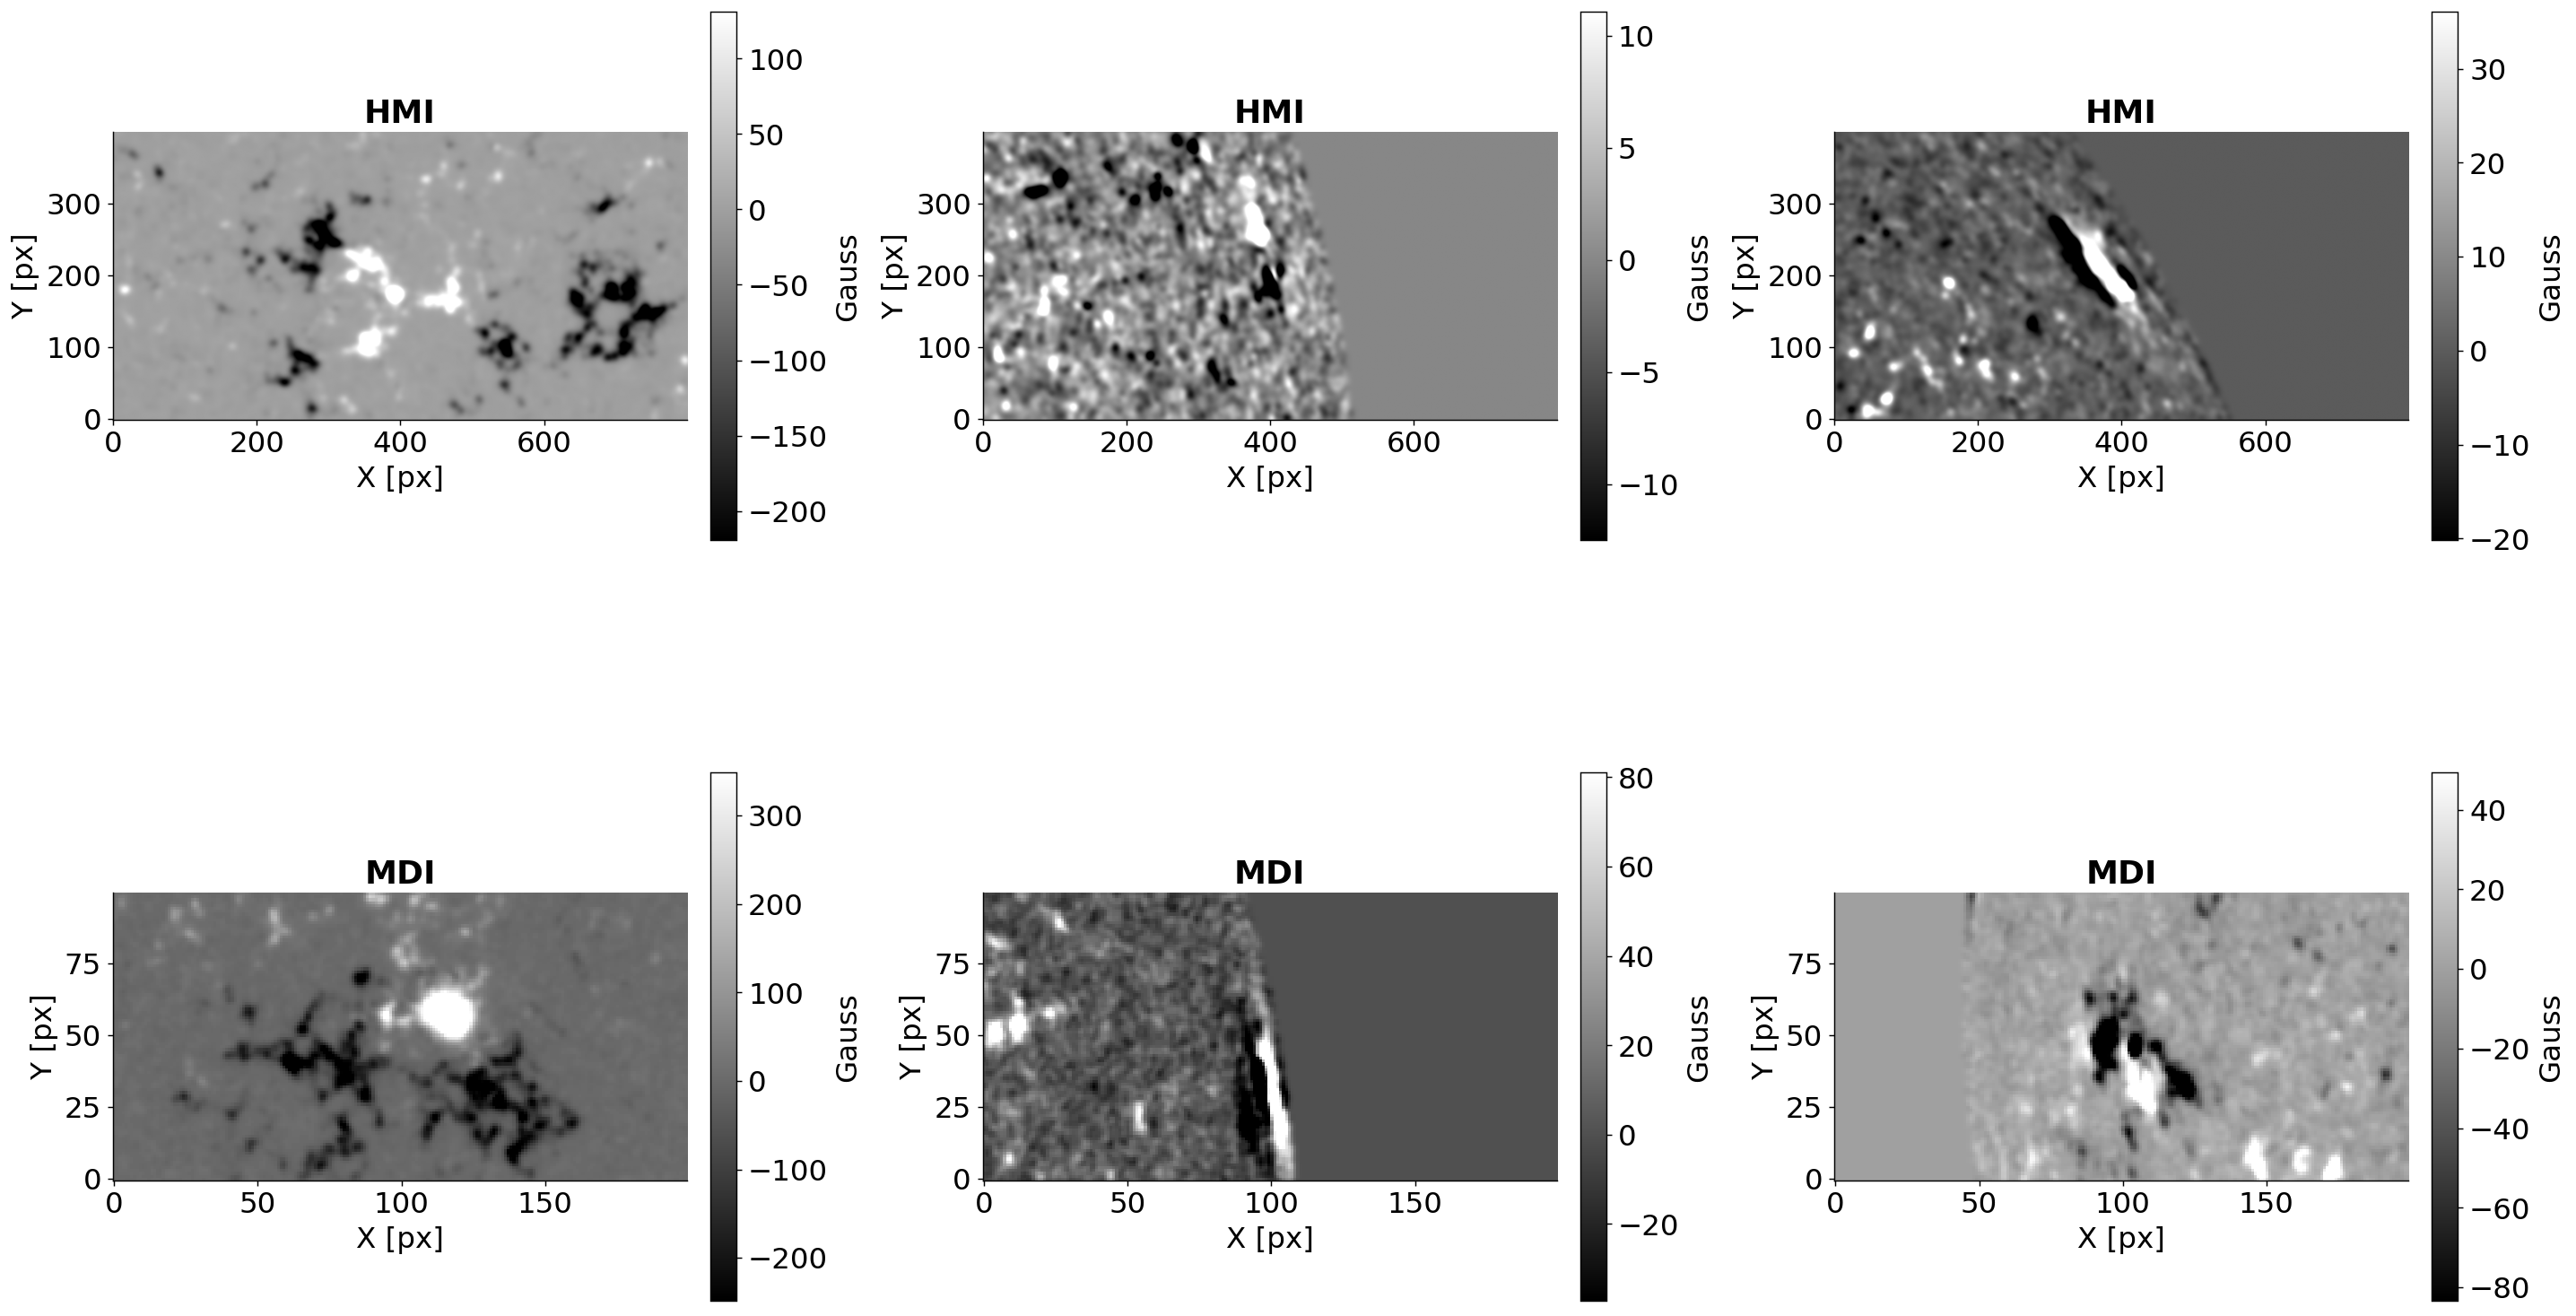

Salvato in: ARCAFF_FINAL/BOXPLOT/magnetograms_6panel.png


In [13]:
# %% Magnetograms: 3 random HMI + 3 random MDI samples, with colorbar, saved as PNG
import pandas as pd
import numpy as np
import h5py
import matplotlib.pyplot as plt
import random
import os

TIMING_CSV = 'Data-cut-flare-number-padded/regression_number_24h_complete_timing.csv'
OUTPUT_DIR  = 'ARCAFF_FINAL/BOXPLOT'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- Load CSV ---
df = pd.read_csv(TIMING_CSV)

# --- Filter HMI and MDI ---
df_hmi = df[df['dataset'] == 'HMI']
df_mdi = df[df['dataset'] == 'MDI']

# --- Pick 3 random samples for each instrument ---
random.seed(7)
sample_hmi = df_hmi.sample(3)
sample_mdi = df_mdi.sample(3)

samples = pd.concat([sample_hmi, sample_mdi])

# --- Helper to read a magnetogram from HDF5 ---
def load_mag(filepath):
    with h5py.File(filepath, 'r') as f:
        for key in f.keys():
            if 'magnetogram' in key.lower() or 'data' in key.lower():
                return f[key][:]
        for key in f.keys():
            if isinstance(f[key], h5py.Dataset):
                return f[key][:]
        return None

# --- Global settings for larger fonts ---
plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 20,
    'axes.labelsize': 18,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
})

# --- Plot ---
fig, axes = plt.subplots(2, 3, figsize=(22, 13), constrained_layout=True)
axes = axes.flatten()

for ax, (_, row) in zip(axes, samples.iterrows()):
    filepath = row['filename']
    if not os.path.exists(filepath):
        ax.text(0.5, 0.5, 'FILE NOT FOUND', ha='center', va='center', fontsize=14)
        ax.set_xticks([]); ax.set_yticks([])
        continue

    data = load_mag(filepath)

    if data is None:
        ax.text(0.5, 0.5, 'NO DATA', ha='center', va='center', fontsize=14)
        ax.set_xticks([]); ax.set_yticks([])
        continue

    # robust stretch for display
    vmin, vmax = np.nanpercentile(data, [1, 99])

    im = ax.imshow(data, cmap='gray', origin='lower', vmin=vmin, vmax=vmax)
    ax.set_title(row.get('dataset', ''), fontsize=20, fontweight='bold')
    ax.set_xlabel("X [px]", fontsize=18)
    ax.set_ylabel("Y [px]", fontsize=18)
    ax.tick_params(axis='both', which='major', labelsize=18)   # <-- larger X/Y tick labels

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Gauss", fontsize=18)
    cbar.ax.tick_params(labelsize=18)   # <-- larger colorbar tick labels

# --- Save PNG ---
out_path = os.path.join(OUTPUT_DIR, "magnetograms_6panel.png")
fig.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Salvato in: {out_path}")

## 3. Load predictions + timing CSV

In [4]:
preds_df  = pd.read_csv(PREDS_CSV)
timing_df = pd.read_csv(TIMING_CSV)
metrics_df = pd.read_csv(METRICS_CSV)

print(f'Predictions: {len(preds_df)} rows')
print(f'Timing CSV:  {len(timing_df)} rows')
print(f'Unique seed×fold×mode: {preds_df.groupby(["seed","fold","mode"]).ngroups}')
print(preds_df.groupby(['mode','split'])['seed'].count().rename('n_samples'))

Predictions: 3193300 rows
Timing CSV:  31933 rows
Unique seed×fold×mode: 100
mode     split     
binary   pseudotest     33290
         test          319330
         train         924700
         val           319330
poisson  pseudotest     33290
         test          319330
         train         924700
         val           319330
Name: n_samples, dtype: int64


In [5]:
import itertools

present = preds_df.groupby(["seed","fold","mode"]).size().reset_index()[["seed","fold","mode"]]

expected = pd.DataFrame(
    list(itertools.product(range(10), range(5), ['poisson','binary'])),
    columns=['seed','fold','mode']
)

missing = expected.merge(present, how='left', indicator=True)
missing[missing['_merge']=='left_only']


,seed,fold,mode,_merge


In [6]:
def parse_pipe_list(s, dtype=float):
    if pd.isna(s) or str(s).strip() == '': return []
    try:    return [dtype(x) for x in str(s).split('|') if x.strip()]
    except: return []

for cls in CLASS_NAMES:
    col = f'{cls}_hours_from_obs'
    timing_df[f'{cls}_hours_list'] = (
        timing_df[col].apply(parse_pipe_list)
        if col in timing_df.columns
        else [[] for _ in range(len(timing_df))])

# Keep only what we need for the join
timing_slim = timing_df[['filename'] + [f'{c}_hours_list' for c in CLASS_NAMES]].copy()

# Join
preds_df = preds_df.merge(timing_slim, on='filename', how='left')
print(f'After join: {len(preds_df)} rows  '
      f'({preds_df["X_hours_list"].notna().sum()} with timing info)')

After join: 3193300 rows  (3193300 with timing info)


## 4. Calibrate τ* per seed × fold × mode

Each run has its own τ* calibrated on its own validation split — same logic as `flare_forecast/training/train.py`.

In [7]:
TAU_MIN, TAU_MAX, N_TAU = 0.01, 2.0, 500

def calibrate_one(sub_val, cls):
    """Grid search τ* = argmax TSS on val subset for one class."""
    yt = sub_val[f'yt_{cls}'].values
    yp = sub_val[f'yp_{cls}'].values
    taus = np.linspace(TAU_MIN,
                       min(TAU_MAX, float(np.percentile(yp, 99)) + 0.1),
                       N_TAU)
    tss_vals = [confusion_skills((yt>=0.5).astype(int),
                                 (yp>=t).astype(int))['TSS']
                for t in taus]
    return float(taus[np.argmax(tss_vals)])


# Compute τ* for every seed×fold×mode
tau_records = []
groups = preds_df[preds_df['split'] == 'val'].groupby(['seed','fold','mode'])
for (seed, fold, mode), sub in groups:
    row = {'seed': seed, 'fold': fold, 'mode': mode}
    for cls in CLASS_NAMES:
        row[f'tau_{cls}'] = calibrate_one(sub, cls)
    tau_records.append(row)

tau_df = pd.DataFrame(tau_records)
print(f'Calibrated {len(tau_df)} runs')
print(tau_df.groupby('mode')[[f'tau_{c}' for c in CLASS_NAMES]].describe().round(4))

Calibrated 100 runs
        tau_C                                                         tau_M  \
        count    mean     std     min     25%     50%     75%     max count   
mode                                                                          
binary   50.0  0.3097  0.0981  0.1101  0.2572  0.2980  0.3811  0.5455  50.0   
poisson  50.0  0.4546  0.0908  0.2652  0.3899  0.4706  0.5165  0.6002  50.0   

                 ...                 tau_X                                \
           mean  ...     75%     max count    mean     std   min     25%   
mode             ...                                                       
binary   0.1095  ...  0.1250  0.3957  50.0  0.0537  0.1327  0.01  0.0137   
poisson  0.0841  ...  0.1065  0.1775  50.0  0.0193  0.0099  0.01  0.0125   

                                 
            50%     75%     max  
mode                             
binary   0.0215  0.0455  0.9423  
poisson  0.0162  0.0214  0.0539  

[2 rows x 24 columns]


In [8]:
# Merge τ* back into predictions
preds_df = preds_df.merge(tau_df, on=['seed','fold','mode'], how='left')

# Compute binary predictions and outcomes
for cls in CLASS_NAMES:
    preds_df[f'pred_bin_{cls}'] = (preds_df[f'yp_{cls}'] >= preds_df[f'tau_{cls}']).astype(int)
    preds_df[f'true_bin_{cls}'] = (preds_df[f'yt_{cls}']  >= 0.5).astype(int)
    pos = preds_df[f'true_bin_{cls}'] == 1
    preds_df[f'outcome_{cls}'] = np.nan
    preds_df.loc[pos, f'outcome_{cls}'] = preds_df.loc[pos, f'pred_bin_{cls}']

print('Binary predictions and outcomes computed.')

Binary predictions and outcomes computed.


## 5. Helper: extract flare hours per outcome

In [9]:
def get_flare_hours(df, cls, window_h=WINDOW_H):
    """
    Returns:
      all_h   — dict {'TP': [...], 'FN': [...]}  all flare hours
      early_h — dict {'TP': [...], 'FN': [...]}  earliest flare per AR sample
    """
    col_hours   = f'{cls}_hours_list'
    col_outcome = f'outcome_{cls}'
    pos = df[df[f'true_bin_{cls}'] == 1]

    all_h  = {'TP': [], 'FN': []}
    early_h = {'TP': [], 'FN': []}

    for _, row in pos.iterrows():
        hours = [h for h in (row[col_hours] or []) if 0 <= h <= window_h]
        label = 'TP' if row[col_outcome] == 1 else 'FN'
        all_h[label].extend(hours)
        if hours:
            early_h[label].append(min(hours))

    return all_h, early_h

## 6. TSS early vs late — per run + aggregated

For each of the 50 runs, compute the TSS separately on early-flaring ARs (0–12 h) and late-flaring ARs (12–24 h), then aggregate across runs.

In [10]:
def tss_early_late_one_run(sub, cls, window_h=WINDOW_H, midpoint=MIDPOINT):
    """
    Compute TSS early / late for a single run subset.
    Returns dict with keys: tss_all, tss_early, tss_late, n_early, n_late
    """
    col_hours = f'{cls}_hours_list'
    rows = []
    for _, row in sub.iterrows():
        hours    = [h for h in (row[col_hours] or []) if 0 <= h <= window_h]
        earliest = min(hours) if hours else None
        rows.append({'true_bin': row[f'true_bin_{cls}'],
                     'pred_bin': row[f'pred_bin_{cls}'],
                     'earliest': earliest})
    tmp = pd.DataFrame(rows)
    neg  = tmp['true_bin'] == 0
    e_mask = tmp['earliest'].notna() & (tmp['earliest'] <  midpoint)
    l_mask = tmp['earliest'].notna() & (tmp['earliest'] >= midpoint)

    result = {'tss_all': confusion_skills(tmp['true_bin'].values,
                                          tmp['pred_bin'].values)['TSS']}
    for key, mask in [('early', e_mask), ('late', l_mask)]:
        sub2 = tmp[mask | neg]
        if sub2['true_bin'].sum() > 0:
            result[f'tss_{key}'] = confusion_skills(
                sub2['true_bin'].values, sub2['pred_bin'].values)['TSS']
            result[f'n_{key}']   = int(mask.sum())
        else:
            result[f'tss_{key}'] = np.nan
            result[f'n_{key}']   = 0
    return result


# Compute for every run × split × class
tss_records = []
for split in ['val', 'test']:
    sub_split = preds_df[preds_df['split'] == split]
    for (seed, fold, mode), sub_run in sub_split.groupby(['seed','fold','mode']):
        for cls in CLASS_NAMES:
            res = tss_early_late_one_run(sub_run, cls)
            tss_records.append({
                'seed': seed, 'fold': fold, 'mode': mode,
                'split': split, 'cls': cls, **res
            })

tss_el = pd.DataFrame(tss_records)
tss_el['delta'] = tss_el['tss_early'] - tss_el['tss_late']
print(f'TSS early/late computed for {len(tss_el)} run×split×class combinations')

TSS early/late computed for 600 run×split×class combinations


In [11]:
# Summary table: mean ± std of delta across runs
summary = (
    tss_el.groupby(['mode','split','cls'])
    [['tss_all','tss_early','tss_late','delta']]
    .agg(['mean','std'])
    .round(4)
)
print(summary.to_string())

                  tss_all         tss_early         tss_late           delta        
                     mean     std      mean     std     mean     std    mean     std
mode    split cls                                                                   
binary  test  C    0.4631  0.0233    0.4929  0.0283   0.4092  0.0224  0.0838  0.0288
              M    0.5812  0.0513    0.6038  0.0460   0.5550  0.0704  0.0489  0.0627
              X    0.6827  0.1370    0.6621  0.1818   0.6907  0.1736 -0.0285  0.2185
        val   C    0.4707  0.0237    0.4972  0.0314   0.4224  0.0221  0.0748  0.0355
              M    0.6075  0.0532    0.6316  0.0416   0.5779  0.0719  0.0538  0.0514
              X    0.7374  0.1495    0.7278  0.1833   0.7397  0.1544 -0.0119  0.1566
poisson test  C    0.4901  0.0215    0.5229  0.0252   0.4310  0.0211  0.0919  0.0259
              M    0.6219  0.0397    0.6436  0.0353   0.5965  0.0605  0.0471  0.0599
              X    0.7412  0.0987    0.7231  0.1248   0.7557  0.1

## 7. Single-fold checks by active region

In [17]:
# ══════════════════════════════════════════════════════════════
# EXTRA CHECKS — Single fold analysis by Active Region
# ══════════════════════════════════════════════════════════════

# Look for a seed×fold where the focus AR is in the test split

# Join predictions with timing to get ar_number
timing_key = timing_df[['filename', 'ar_number', 'sample_time']].drop_duplicates()

df_all = preds_df[preds_df['mode'] == 'binary'].copy()
df_all = df_all.merge(timing_key, on='filename', how='left')

# Find a seed×fold where the focus AR appears in the test split
AR_FOCUS = 12673

candidates = (
    df_all[
        (df_all['ar_number'] == AR_FOCUS) &
        (df_all['split'] == 'test')
    ]
    .groupby(['seed', 'fold'])
    .size()
    .reset_index(name='n_samples')
)

print(f"Seed×fold combinations where AR {AR_FOCUS} is in the test split:")
print(candidates.to_string(index=False))

# Pick the first valid seed×fold (or set manually)
if len(candidates) == 0:
    print(f"AR {AR_FOCUS} never appears in test — check val/pseudotest splits")
    # fallback: find which splits contain it
    print(df_all[df_all['ar_number'] == AR_FOCUS]['split'].value_counts())
else:
    SEED = candidates.iloc[0]['seed']
    FOLD = candidates.iloc[0]['fold']
    print(f"Selected seed={SEED}, fold={FOLD}  ({candidates.iloc[0]['n_samples']} samples for AR {AR_FOCUS})")

    # Subset: single fold, test split only
    df_fold = df_all[
        (df_all['seed'] == SEED) &
        (df_all['fold'] == FOLD) &
        (df_all['split'] == 'test')
    ].copy()

    print(f"\nTotal test samples in this fold: {len(df_fold)}")
    print(f"Unique ARs in test: {df_fold['ar_number'].nunique()}")

Seed×fold combinations where AR 12673 is in the test split:
 seed  fold  n_samples
    0     4         12
    1     4         12
    2     4         12
    3     4         12
    4     4         12
    5     4         12
    6     4         12
    7     4         12
    8     4         12
    9     4         12
Selected seed=0, fold=4  (12 samples for AR 12673)

Total test samples in this fold: 6416
Unique ARs in test: 995


## 8. TPR (sensitivity) and TNR (specificity)

Across runs, for each split, mode and class.

In [19]:
# ══════════════════════════════════════════════════════════════
# ANALYSIS 1 — TPR (Sensitivity) & TNR (Specificity)
# splits: train, val, test | modes: binary vs poisson | classes: C, M, X
# ══════════════════════════════════════════════════════════════

import seaborn as sns

SPLITS  = ['train', 'val', 'test']
CLASSES = ['C', 'M', 'X']
MODES   = ['binary', 'poisson']
cls_colors = {'C': '#378ADD', 'M': '#1D9E75', 'X': '#D85A30'}
mode_ls    = {'binary': '-', 'poisson': '--'}

# Build tidy dataframe from metrics_df
# Each row: seed, fold, mode, split, class, TPR, TNR
records = []
for _, row in metrics_df.iterrows():
    for split in SPLITS:
        for cls in CLASSES:
            tpr_col = f'{split}_TPR_{cls}'
            tnr_col = f'{split}_TNR_{cls}'
            if tpr_col not in metrics_df.columns:
                continue
            records.append({
                'seed':  row['seed'],
                'fold':  row['fold'],
                'mode':  row['mode'],
                'split': split,
                'class': cls,
                'TPR':   row[tpr_col],   # sensitivity
                'TNR':   row[tnr_col],   # specificity
                'TSS':   row[tpr_col] + row[tnr_col] - 1,  # TPR + TNR - 1
            })

df_perf = pd.DataFrame(records)

# ── Summary table: mean ± std per split × class × mode ───────────────────────

print("\nTPR (Sensitivity) — mean ± std across seeds×folds")
print("=" * 70)
for metric in ['TPR', 'TNR', 'TSS']:
    print(f"\n{'─'*70}\n  {metric}\n{'─'*70}")
    pivot = (df_perf
             .groupby(['split', 'class', 'mode'])[metric]
             .agg(['mean', 'std'])
             .reset_index())
    pivot['mean±std'] = (pivot['mean'].map('{:.3f}'.format) +
                         ' ± ' + pivot['std'].map('{:.3f}'.format))
    tbl = pivot.pivot_table(
        index=['split', 'class'], columns='mode',
        values='mean±std', aggfunc='first'
    ).reindex(SPLITS, level='split')
    print(tbl.to_string())


TPR (Sensitivity) — mean ± std across seeds×folds

──────────────────────────────────────────────────────────────────────
  TPR
──────────────────────────────────────────────────────────────────────
mode                binary        poisson
split class                              
train C      0.728 ± 0.038  0.748 ± 0.031
      M      0.805 ± 0.045  0.864 ± 0.057
      X      0.897 ± 0.087  0.920 ± 0.093
val   C      0.734 ± 0.040  0.754 ± 0.032
      M      0.812 ± 0.055  0.853 ± 0.041
      X      0.905 ± 0.061  0.921 ± 0.083
test  C      0.726 ± 0.040  0.745 ± 0.033
      M      0.785 ± 0.062  0.834 ± 0.056
      X      0.825 ± 0.116  0.844 ± 0.120

──────────────────────────────────────────────────────────────────────
  TNR
──────────────────────────────────────────────────────────────────────
mode                binary        poisson
split class                              
train C      0.738 ± 0.037  0.747 ± 0.025
      M      0.797 ± 0.040  0.791 ± 0.048
      X      0.875 ± 

"\n    # ── Plot 1: Boxplot TPR and TNR — binary vs poisson, per class and split ──────\n\nfig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey=False)\n\nfor col, cls in enumerate(CLASSES):\n    for row, metric in enumerate(['TPR', 'TNR']):\n        ax = axes[row, col]\n        df_sub = df_perf[df_perf['class'] == cls]\n        sns.boxplot(\n            data=df_sub, x='split', y=metric, hue='mode',\n            order=SPLITS, palette={'binary': '#4C72B0', 'poisson': '#DD8452'},\n            ax=ax, width=0.5, linewidth=1.2\n        )\n        ax.set_title(f'Class {cls} — {metric}')\n        ax.set_xlabel('')\n        ax.set_ylabel(metric if col == 0 else '')\n        ax.set_ylim(-0.05, 1.05)\n        ax.axhline(0.5, color='gray', lw=0.8, ls=':')\n        if row == 0 and col == 2:\n            ax.legend(loc='lower right', fontsize=9)\n        else:\n            ax.get_legend().remove()\n\nplt.suptitle('Sensitivity (TPR) and Specificity (TNR)\nbinary vs poisson — train / val / test',\n  

## 9. Case study: AR 12673, fold 4

In [20]:
# ══════════════════════════════════════════════════════════════
# ANALYSIS 2 — Case Study: AR 12673, fold 4
# ══════════════════════════════════════════════════════════════

AR_CS   = 12673
FOLD_CS = 4

timing_key = timing_df[['filename', 'ar_number', 'sample_time']].drop_duplicates()

df_cs_raw = preds_df[
    (preds_df['fold']  == FOLD_CS) &
    (preds_df['split'] == 'test')
].merge(timing_key, on='filename', how='left')

df_cs_raw = df_cs_raw[df_cs_raw['ar_number'] == AR_CS].copy()
df_cs_raw['sample_time'] = pd.to_datetime(df_cs_raw['sample_time'])
df_cs_raw = df_cs_raw.sort_values(['mode','seed','sample_time']).reset_index(drop=True)

print(f"AR {AR_CS}, fold {FOLD_CS}, test: {len(df_cs_raw)} rows")
print(f"Seeds: {sorted(df_cs_raw['seed'].unique())}")
print(f"Modes: {list(df_cs_raw['mode'].unique())}")
print(f"Timesteps: {df_cs_raw['sample_time'].nunique()}")

print(f"\nTrue values (constant across seeds):")
ref = (df_cs_raw[df_cs_raw['mode']=='binary']
       .drop_duplicates('sample_time')
       .sort_values('sample_time'))
print(ref[['sample_time','yt_C','yt_M','yt_X']].to_string(index=False))

# ── Seed-by-seed table ────────────────────────────────────────────────────────

print(f"\nAR {AR_CS}, fold {FOLD_CS} — seed-by-seed predictions\n")

for seed in sorted(df_cs_raw['seed'].unique()):
    df_bin = df_cs_raw[(df_cs_raw['seed']==seed) & (df_cs_raw['mode']=='binary')].sort_values('sample_time')
    df_poi = df_cs_raw[(df_cs_raw['seed']==seed) & (df_cs_raw['mode']=='poisson')].sort_values('sample_time')

    tau_b = df_bin.iloc[0][['tau_C','tau_M','tau_X']] if len(df_bin) else [None]*3
    tau_p = df_poi.iloc[0][['tau_C','tau_M','tau_X']] if len(df_poi) else [None]*3

    print(f"  {'─'*100}")
    print(f"  Seed {seed}  |  "
          f"poisson tau=({tau_p['tau_C']:.3f},{tau_p['tau_M']:.3f},{tau_p['tau_X']:.3f})  |  "
          f"binary  tau=({tau_b['tau_C']:.3f},{tau_b['tau_M']:.3f},{tau_b['tau_X']:.3f})")
    print(f"  {'─'*100}")
    print(f"  {'date':<12}  {'true(C,M,X)':>13}  "
          f"{'poi_lambda':>22}  {'poi_th':>10}  "
          f"{'bin_yp':>22}  {'bin_th':>10}  flags")
    print(f"  {'':─<100}")

    for t in sorted(df_poi['sample_time'].unique()):
        rp = df_poi[df_poi['sample_time']==t]
        rb = df_bin[df_bin['sample_time']==t]
        if rp.empty or rb.empty:
            continue
        rp = rp.iloc[0]; rb = rb.iloc[0]

        true_str  = f"({rp['yt_C']:.0f},{rp['yt_M']:.0f},{rp['yt_X']:.0f})"
        poi_l_str = f"({rp['yp_C']:.3f},{rp['yp_M']:.3f},{rp['yp_X']:.3f})"
        bin_y_str = f"({rb['yp_C']:.3f},{rb['yp_M']:.3f},{rb['yp_X']:.3f})"
        # use pre-computed pred_bin and true_bin from preds_df
        poi_t_str = f"({rp['pred_bin_C']:.0f},{rp['pred_bin_M']:.0f},{rp['pred_bin_X']:.0f})"
        bin_t_str = f"({rb['pred_bin_C']:.0f},{rb['pred_bin_M']:.0f},{rb['pred_bin_X']:.0f})"

        flags = ''
        for cls in CLASS_NAMES:
            if rp[f'pred_bin_{cls}'] != rp[f'true_bin_{cls}']:
                flags += f' poi_{cls} no'
            if rb[f'pred_bin_{cls}'] != rb[f'true_bin_{cls}']:
                flags += f' bin_{cls} no'

        print(f"  {str(t)[:10]:<12}  {true_str:>13}  "
              f"{poi_l_str:>22}  {poi_t_str:>10}  "
              f"{bin_y_str:>22}  {bin_t_str:>10}  {flags}")
    print()

# ── Aggregate across seeds: hit rate per timestep ────────────────────────────

print(f"\nAR {AR_CS}, fold {FOLD_CS} — hit rate across seeds per timestep\n")
print(f"  Positive sample (yt>0) → fraction of seeds with pred_bin=1 (sensitivity)")
print(f"  Negative sample (yt=0) → fraction of seeds with pred_bin=0 (specificity)\n")

print(f"  {'date':<12}  {'true':>12}  "
      f"{'poi_C':>7} {'poi_M':>7} {'poi_X':>7}  "
      f"{'bin_C':>7} {'bin_M':>7} {'bin_X':>7}")
print(f"  {'':─<80}")

for t in sorted(df_cs_raw['sample_time'].unique()):
    df_t  = df_cs_raw[df_cs_raw['sample_time']==t]
    dp    = df_t[df_t['mode']=='poisson']
    db    = df_t[df_t['mode']=='binary']

    true_str = f"({dp['yt_C'].iloc[0]:.0f},{dp['yt_M'].iloc[0]:.0f},{dp['yt_X'].iloc[0]:.0f})"

    def hit(df_m, cls):
        is_pos = df_m[f'true_bin_{cls}'].iloc[0] == 1
        if is_pos:
            return (df_m[f'pred_bin_{cls}'] == 1).mean()
        else:
            return (df_m[f'pred_bin_{cls}'] == 0).mean()

    print(f"  {str(t)[:10]:<12}  {true_str:>12}  "
          f"{hit(dp,'C'):>7.1%} {hit(dp,'M'):>7.1%} {hit(dp,'X'):>7.1%}  "
          f"{hit(db,'C'):>7.1%} {hit(db,'M'):>7.1%} {hit(db,'X'):>7.1%}")

AR 12673, fold 4, test: 240 rows
Seeds: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Modes: ['binary', 'poisson']
Timesteps: 12

True values (constant across seeds):
        sample_time  yt_C  yt_M  yt_X
2017-08-29 23:58:42   0.0   0.0   0.0
2017-08-30 23:58:42   0.0   0.0   0.0
2017-08-31 23:58:42   0.0   0.0   0.0
2017-09-01 23:58:42   0.0   0.0   0.0
2017-09-02 23:58:42   1.0   0.0   0.0
2017-09-03 23:58:42   7.0   7.0   0.0
2017-09-04 23:58:42   7.0   5.0   0.0
2017-09-05 23:58:42   2.0   2.0   2.0
2017-09-06 23:58:41   7.0   3.0   1.0
2017-09-07 23:58:41  16.0   6.0   0.0
2017-09-08 23:58:41  10.0   3.0   0.0
2017-09-09 23:58:41   4.0   0.0   1.0

AR 12673, fold 4 — seed-by-seed predictions

  ────────────────────────────────────────────────────────────────────────────────────────────────────
  Seed 0  |  poisson tau=(0.277,0.052,0.010)  |  binary  tau=(0.315,0.106,0.014)
  ────────────────────────────────────────────────────────────────────────────────────────────────────
  date            tru

## 10. Per-AR detection of flare samples for a single seed (test split)

In [23]:
# ══════════════════════════════════════════════════════════════
# ANALYSIS 3 — All flare samples (yt_M > 0) for a single seed
# preds_df already has pred_bin_*, true_bin_*, tau_* — just filter
# ══════════════════════════════════════════════════════════════

SEED_M = 3  # change to any seed 0-9

timing_key = timing_df[['filename', 'ar_number', 'sample_time']].drop_duplicates()

df_seed = preds_df[
    (preds_df['seed']  == SEED_M) &
    (preds_df['split'] == 'test')
].merge(timing_key, on='filename', how='left').copy()

df_seed['sample_time'] = pd.to_datetime(df_seed['sample_time'])

# Keep only samples where yt_M > 0
df_Mflares = df_seed[df_seed['yt_M'] > 0].copy()
df_Mflares = df_Mflares.sort_values(['mode','ar_number','sample_time'])

print(f"Seed {SEED_M} — test samples with yt_M > 0: "
      f"{df_Mflares[df_Mflares['mode']=='binary']['filename'].nunique()} unique timesteps "
      f"across {df_Mflares['ar_number'].nunique()} ARs")
print(f"ARs with X-flare: {sorted(df_Mflares['ar_number'].unique())}")

# ── Sample-level table ────────────────────────────────────────────────────────

print(f"\nSeed {SEED_M} — all X-flare samples in test\n")
print(f"{'AR':>6}  {'date':<12}  {'true':>13}  "
      f"{'poi_lambda':>22}  {'poi_th':>10}  "
      f"{'bin_yp':>22}  {'bin_th':>10}  ok?")
print("─" * 115)

for ar in sorted(df_Mflares['ar_number'].unique()):
    dp_ar = df_Mflares[(df_Mflares['ar_number']==ar) & (df_Mflares['mode']=='poisson')]
    db_ar = df_Mflares[(df_Mflares['ar_number']==ar) & (df_Mflares['mode']=='binary')]

    for t in sorted(dp_ar['sample_time'].unique()):
        rp = dp_ar[dp_ar['sample_time']==t]
        rb = db_ar[db_ar['sample_time']==t]
        if rp.empty or rb.empty:
            continue
        rp = rp.iloc[0]; rb = rb.iloc[0]

        true_str  = f"({rp['yt_C']:.0f},{rp['yt_M']:.0f},{rp['yt_M']:.0f})"
        poi_l_str = f"({rp['yp_C']:.3f},{rp['yp_M']:.3f},{rp['yp_M']:.3f})"
        poi_t_str = f"({rp['pred_bin_C']:.0f},{rp['pred_bin_M']:.0f},{rp['pred_bin_M']:.0f})"
        bin_y_str = f"({rb['yp_C']:.3f},{rb['yp_M']:.3f},{rb['yp_M']:.3f})"
        bin_t_str = f"({rb['pred_bin_C']:.0f},{rb['pred_bin_M']:.0f},{rb['pred_bin_M']:.0f})"

        poi_ok = 'yes' if rp['pred_bin_M'] == rp['true_bin_M'] else 'no'
        bin_ok = 'yes' if rb['pred_bin_M'] == rb['true_bin_M'] else 'no'

        print(f"{ar:>6}  {str(t)[:10]:<12}  {true_str:>13}  "
              f"{poi_l_str:>22}  {poi_t_str:>10}  "
              f"{bin_y_str:>22}  {bin_t_str:>10}  P:{poi_ok} B:{bin_ok}")
    print()

# ── Summary: poisson vs binary on X-class detection ─────────────────────────

print(f"\nSeed {SEED_M} — X-class detection: poisson vs binary (test) - 1 count for each event\n") # NB: each sample counts once even if the same AR has several flares of that class: e.g. AR 12673 has 4 X flares over 3 timestamps, so only those 3 timestamps are reported, together with how many of them were predicted
print(f"{'AR':>6}  {'n_M':>4}  {'poisson':>8}  {'binary':>8}  winner")
print("─" * 45)

all_ar_M = sorted(df_Mflares['ar_number'].unique())
df_all_seed = df_seed[df_seed['ar_number'].isin(all_ar_M)]

poi_all_tp = poi_all_n = bin_all_tp = bin_all_n = 0

for ar in all_ar_M:
    sub_M_p = df_all_seed[(df_all_seed['ar_number']==ar) & (df_all_seed['mode']=='poisson') & (df_all_seed['yt_M']>0)]
    sub_M_b = df_all_seed[(df_all_seed['ar_number']==ar) & (df_all_seed['mode']=='binary')  & (df_all_seed['yt_M']>0)]

    poi_tp = (sub_M_p['pred_bin_M'] == 1).sum()
    bin_tp = (sub_M_b['pred_bin_M'] == 1).sum()
    n      = len(sub_M_p)

    poi_all_tp += poi_tp; poi_all_n += n
    bin_all_tp += bin_tp; bin_all_n += n

    winner = ('poisson' if poi_tp > bin_tp else
              'binary'  if bin_tp > poi_tp else 'tie')

    print(f"{ar:>6}  {n:>4}  {poi_tp}/{n}  {bin_tp}/{n}  {winner}")

print("─" * 45)
winner_tot = ('poisson' if poi_all_tp > bin_all_tp else
              'binary'  if bin_all_tp > poi_all_tp else 'tie')
print(f"{'TOTAL':>6}  {poi_all_n:>4}  "
      f"{poi_all_tp}/{poi_all_n}  "
      f"{bin_all_tp}/{bin_all_n}  {winner_tot}")
print(f"\npoisson: {poi_all_tp}/{poi_all_n} ({poi_all_tp/poi_all_n:.1%})  |  "
      f"binary: {bin_all_tp}/{bin_all_n} ({bin_all_tp/bin_all_n:.1%})")

Seed 3 — test samples with yt_M > 0: 853 unique timesteps across 435 ARs
ARs with X-flare: [7978, 7999, 8026, 8113, 8179, 8185, 8195, 8214, 8375, 8392, 8409, 8415, 8457, 8471, 8485, 8487, 8508, 8525, 8526, 8534, 8552, 8562, 8583, 8598, 8603, 8611, 8636, 8639, 8647, 8649, 8651, 8656, 8672, 8674, 8739, 8749, 8753, 8759, 8763, 8766, 8768, 8771, 8806, 8807, 8858, 8869, 8872, 8886, 8889, 8906, 8910, 8925, 8926, 8936, 8939, 8948, 8971, 8977, 8993, 8998, 9002, 9026, 9031, 9040, 9041, 9042, 9046, 9070, 9071, 9077, 9085, 9087, 9090, 9143, 9165, 9182, 9213, 9221, 9231, 9235, 9236, 9267, 9289, 9302, 9311, 9313, 9334, 9368, 9373, 9390, 9393, 9401, 9415, 9433, 9445, 9488, 9511, 9557, 9591, 9600, 9601, 9607, 9608, 9616, 9628, 9632, 9653, 9658, 9661, 9671, 9672, 9682, 9684, 9690, 9698, 9704, 9714, 9715, 9718, 9727, 9739, 9742, 9748, 9751, 9754, 9767, 9773, 9775, 9802, 9830, 9866, 9885, 9893, 9899, 9906, 9954, 9973, 10017, 10030, 10039, 10044, 10057, 10061, 10066, 10067, 10069, 10078, 10083, 10085, 10

## 11. Lambda calibration — Poisson log-link, conditional on `pred_bin`

Case studies for selected (AR, fold) pairs.

  Class C: 138610 positives  |  a=0.7499, b=0.3061  |  mean yt=2.11  mean λ_raw=1.35  mean λ_cal=2.11
  Class C: 138610 positives  |  a=0.7499, b=0.3061  |  mean yt=2.11  mean λ_raw=1.35  mean λ_cal=2.11
  Class M: 24720 positives  |  a=0.5619, b=0.1854  |  mean yt=1.46  mean λ_raw=0.63  mean λ_cal=1.46
  Class M: 24720 positives  |  a=0.5619, b=0.1854  |  mean yt=1.46  mean λ_raw=0.63  mean λ_cal=1.46
  Class X: 3080 positives  |  a=0.1560, b=0.0321  |  mean yt=1.10  mean λ_raw=0.40  mean λ_cal=1.10
  Class X: 3080 positives  |  a=0.1560, b=0.0321  |  mean yt=1.10  mean λ_raw=0.40  mean λ_cal=1.10


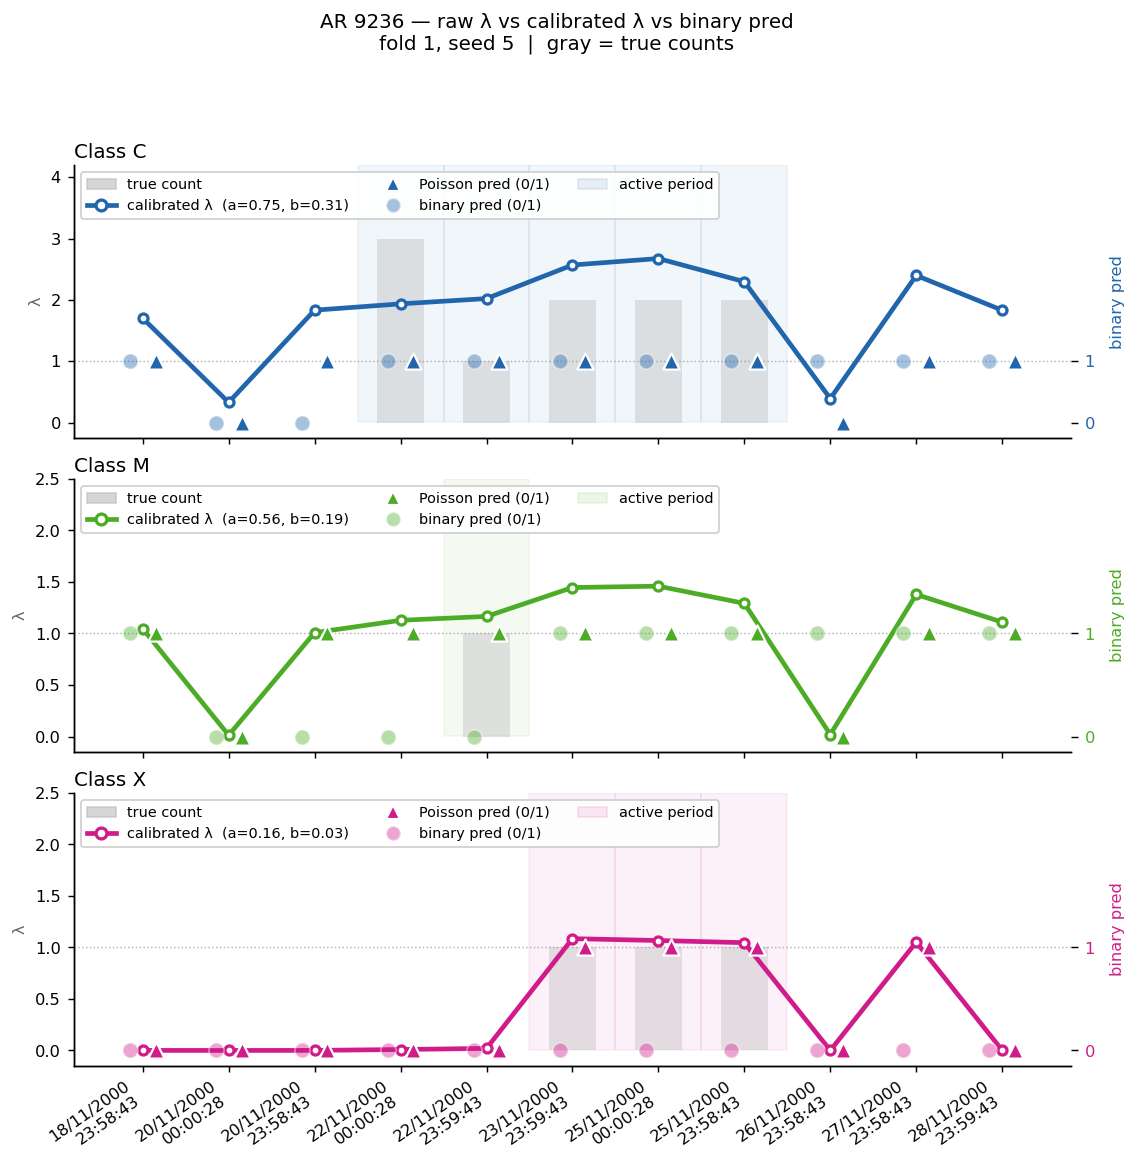

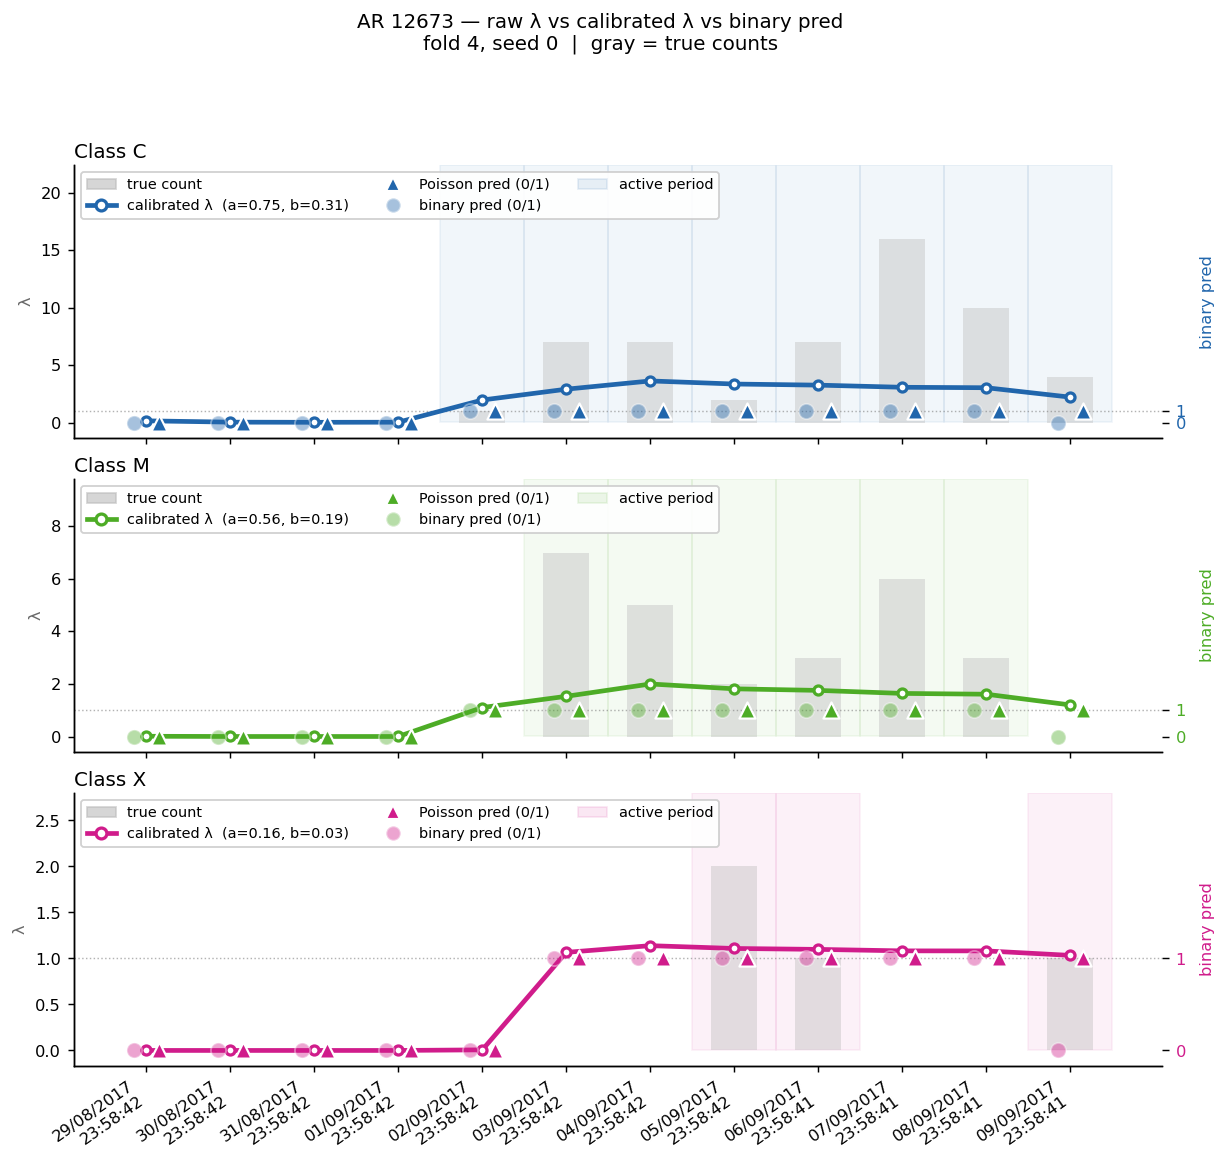

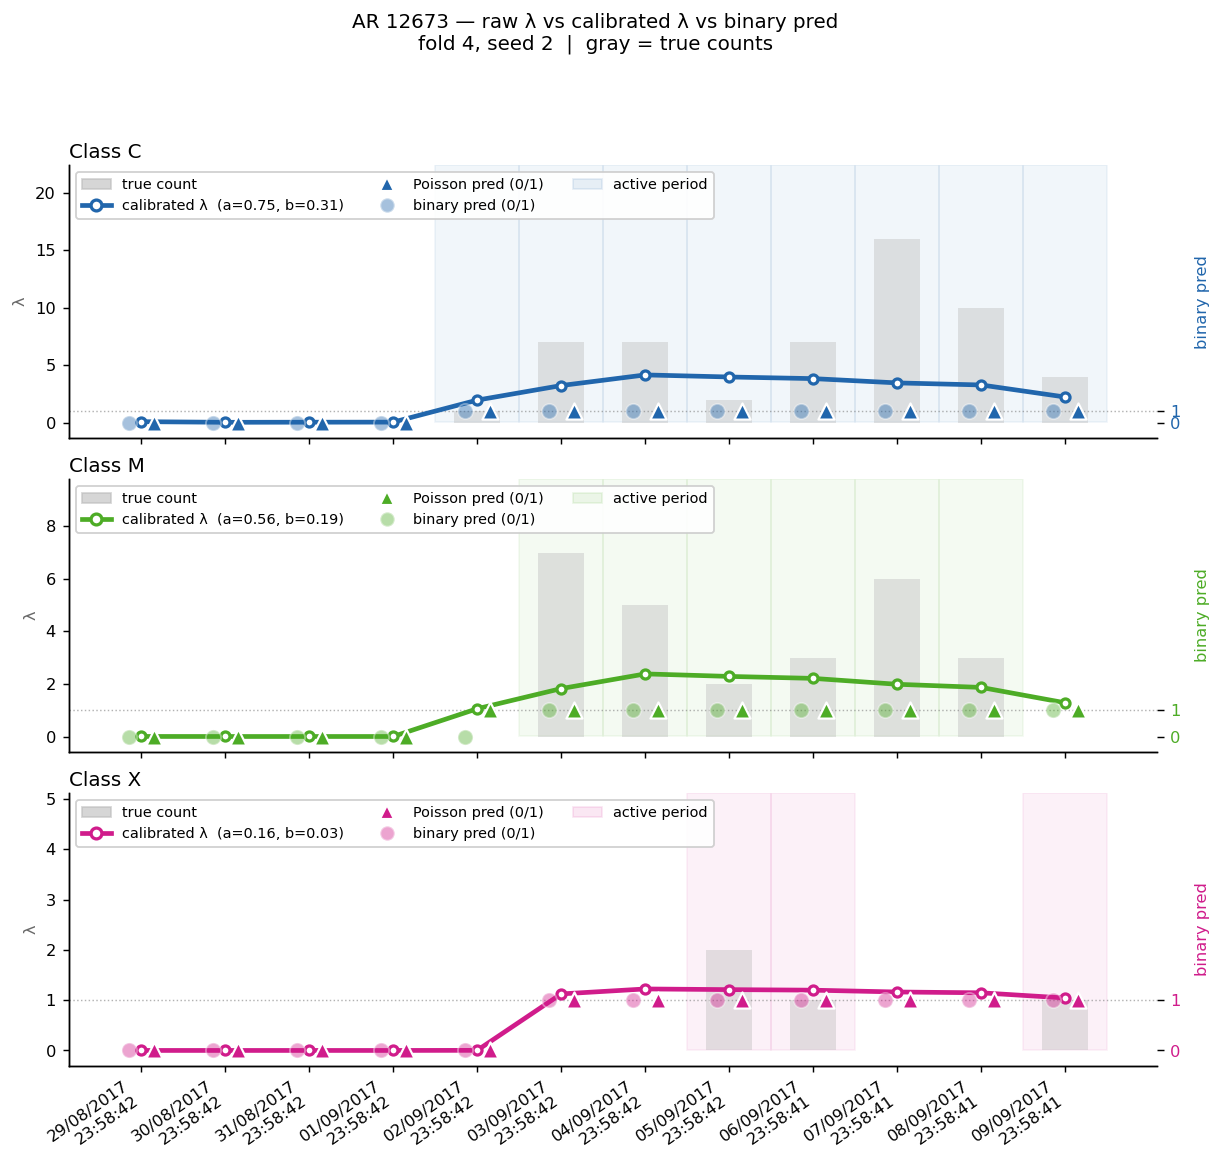

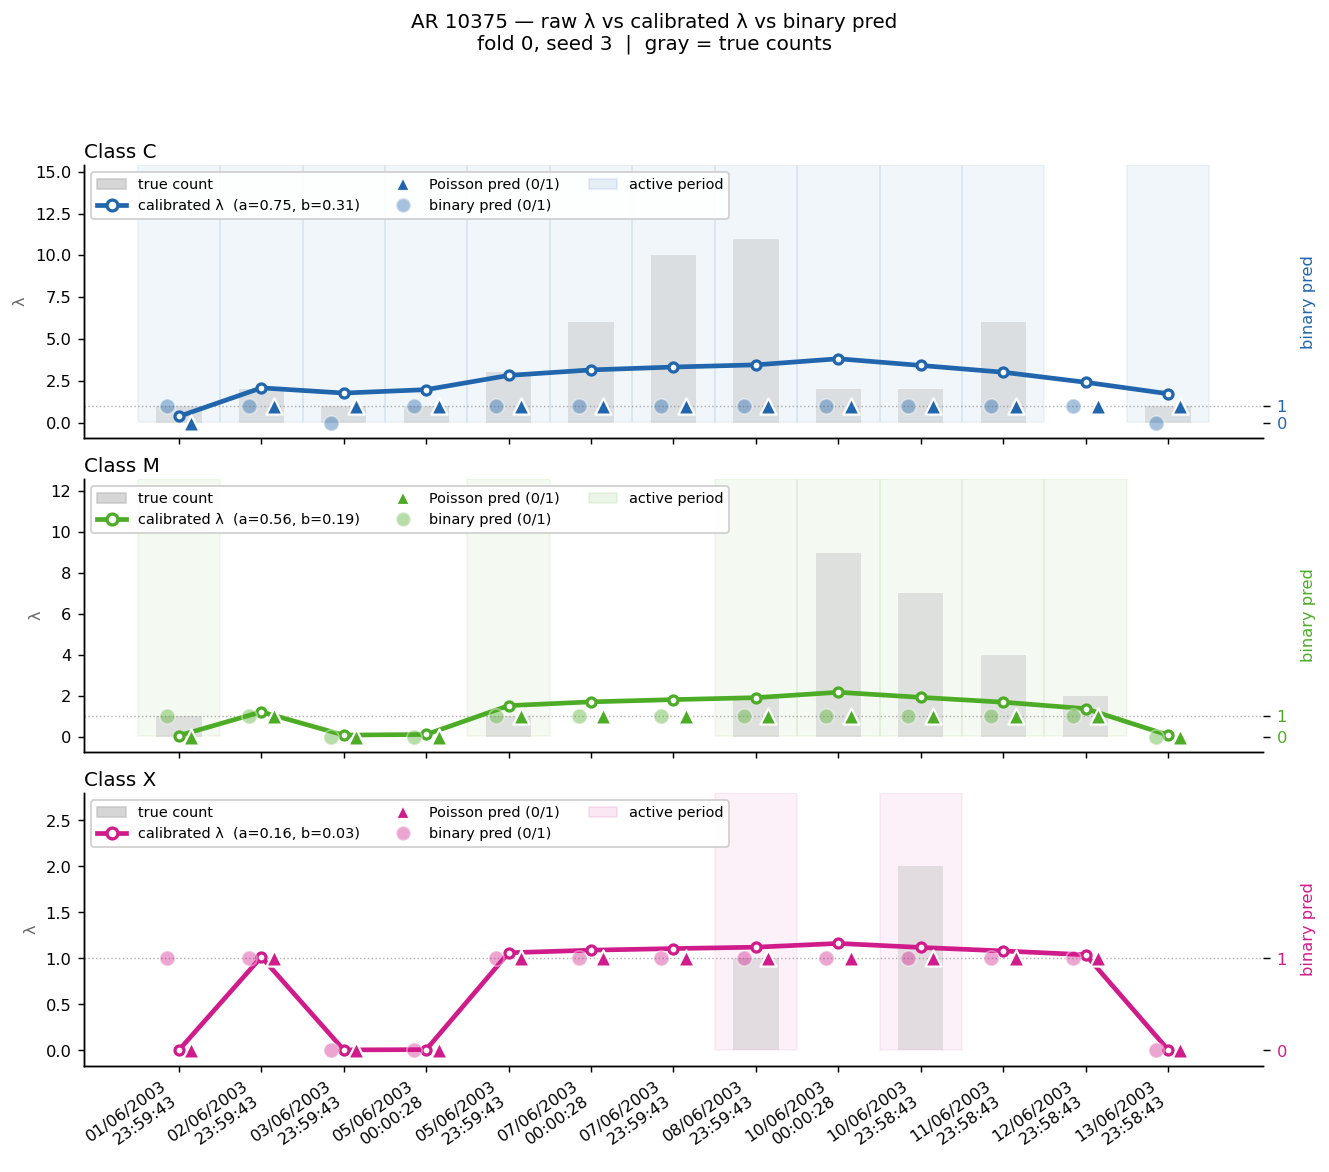

In [25]:
# ══════════════════════════════════════════════════════════════
# LAMBDA CALIBRATION — Poisson log-link, conditional on pred_bin
# ══════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from scipy.optimize import minimize

CLASS_NAMES = ['C', 'M', 'X']
CLS_COLOR   = {'C': '#2166ac', 'M': '#4dac26', 'X': '#d01c8b'}
EPS         = 1e-6

CASES = [
    (9236,  5),
    #(11748, 7),
    #(11890, 5),
    (12673, 0),
    (12673, 2),
    (10375, 3),

]

# ── 1. Data ───────────────────────────────────────────────────

timing_key = timing_df[['filename', 'ar_number', 'sample_time']].drop_duplicates()

df_train = (
    preds_df[(preds_df['split'] == 'train') & (preds_df['mode'] == 'poisson')]
    .merge(timing_key, on='filename', how='left')
)

df_all = (
    preds_df[preds_df['split'] == 'test']
    .merge(timing_key, on='filename', how='left')
)
df_all['sample_time'] = pd.to_datetime(df_all['sample_time'])

# ── 2. Fit calibration coefficients (on samples where yt > 0) ────────────────

def neg_log_lik_poisson(params, log_lam_raw, yt):
    a, b = params
    mu = np.clip(np.exp(a + b * log_lam_raw), EPS, 1e6)
    return -np.sum(yt * np.log(mu) - mu)


calib_params = {}

for cls in CLASS_NAMES:
    yt      = df_train[f'yt_{cls}'].values.astype(float)
    lam_raw = df_train[f'yp_{cls}'].values.astype(float)

    mask    = yt > 0
    yt_pos  = yt[mask]
    lam_pos = lam_raw[mask]
    log_lam = np.log(lam_pos + EPS)
    
    res = minimize(neg_log_lik_poisson, x0=[0.0, 1.0],
                   args=(log_lam, yt_pos),
                   method='Nelder-Mead',
                   options={'xatol': 1e-6, 'fatol': 1e-6, 'maxiter': 10000})

    a, b = res.x
    calib_params[cls] = (a, b)
    mu_pred = np.exp(a + b * log_lam)
    print(f"  Class {cls}: {mask.sum():4d} positives  |  "
          f"a={a:.4f}, b={b:.4f}  |  "
          f"mean yt={yt_pos.mean():.2f}  "
          f"mean λ_raw={lam_pos.mean():.2f}  "
          f"mean λ_cal={mu_pred.mean():.2f}")
    '''
    import statsmodels.api as sm
    X = sm.add_constant(log_lam)
    model = sm.GLM(yt_pos, X, family=sm.families.Poisson())
    result = model.fit()
    a, b = result.params 
    '''
    calib_params[cls] = (a, b)
    mu_pred = np.exp(a + b * log_lam)
    print(f"  Class {cls}: {mask.sum():4d} positives  |  "
          f"a={a:.4f}, b={b:.4f}  |  "
          f"mean yt={yt_pos.mean():.2f}  "
          f"mean λ_raw={lam_pos.mean():.2f}  "
          f"mean λ_cal={mu_pred.mean():.2f}")

# ── 3. Conditional calibration function ──────────────────────────────────────

def calibrate(lam_raw, pred_bin, cls):
    """Calibrate λ only where pred_bin=1; pass through raw λ otherwise."""
    a, b = calib_params[cls]
    return np.where(
        pred_bin == 1,
        np.exp(a + b * np.log(lam_raw + EPS)),
        lam_raw
    )

# ── 4. Plot ───────────────────────────────────────────────────────────────────

def plot_ar_calib(ar, seed):
    df_ar = df_all[df_all['ar_number'] == ar]
    fold  = df_ar['fold'].unique()[0]

    df_bin = (df_ar[(df_ar['seed'] == seed) & (df_ar['mode'] == 'binary')
                    & (df_ar['fold'] == fold)]
              .sort_values('sample_time').reset_index(drop=True))
    df_poi = (df_ar[(df_ar['seed'] == seed) & (df_ar['mode'] == 'poisson')
                    & (df_ar['fold'] == fold)]
              .sort_values('sample_time').reset_index(drop=True))

    if df_poi.empty or df_bin.empty:
        print(f"AR {ar}: empty"); return

    times   = df_poi['sample_time'].values
    x       = np.arange(len(times))
    xlabels = [str(t)[:10] for t in times]
    xlabels = [pd.Timestamp(t).strftime('%d/%m/%Y\n%H:%M:%S') for t in times]

    lam_calib = {cls: calibrate(df_poi[f'yp_{cls}'].values,
                                df_poi[f'pred_bin_{cls}'].values,
                                cls)
                 for cls in CLASS_NAMES}

    hoff = 0.15

    fig, axes = plt.subplots(3, 1, figsize=(max(9, len(times) * 0.9), 9),
                             sharex=True, gridspec_kw={'hspace': 0.15})
    fig.suptitle(
        f'AR {ar} — raw λ vs calibrated λ vs binary pred\n'
        f'fold {fold}, seed {seed}  |  gray = true counts',
        fontsize=11, y=1.01
    )

    for ax, cls in zip(axes, CLASS_NAMES):
        col      = CLS_COLOR[cls]
        yt       = df_poi[f'yt_{cls}'].values
        lam_raw  = df_poi[f'yp_{cls}'].values
        lam_cal  = lam_calib[cls]
        pred_bin = df_bin[f'pred_bin_{cls}'].values
        pred_poi = df_poi[f'pred_bin_{cls}'].values

        # ── per-class y limit ──────────────────────────────────
        ymax = max(
            yt.max()      * 1.40,
            lam_cal.max() * 1.30,
            lam_raw.max() * 1.25,
            2.5
        )

        ax.bar(x, yt, width=0.55, color='#bbbbbb', alpha=0.4, zorder=1)

        for i, v in enumerate(yt):
            if v > 0:
                ax.axvspan(i - 0.5, i + 0.5, color=col, alpha=0.06,
                           zorder=0, ymin=0.06, ymax=1.0)

        ax.axhline(1.0, color='grey', lw=0.8, ls=':', alpha=0.6, zorder=2)

        # ax.plot(x, lam_raw, color=col, lw=1.6, ls='--', zorder=3,
        #         alpha=0.45, marker='o', markersize=4,
        #         markerfacecolor='white', markeredgewidth=1.4)

        ax.plot(x, lam_cal, color=col, lw=2.6, zorder=4,
                marker='o', markersize=5,
                markerfacecolor='white', markeredgewidth=1.8)

        ax.scatter(x - hoff, pred_bin.astype(float), s=70, color=col,
                   alpha=0.4, zorder=5, marker='o',
                   edgecolors='white', linewidths=1.0)
        ax.scatter(x + hoff, pred_poi.astype(float), s=80, color=col,
                   zorder=5, marker='^',
                   edgecolors='white', linewidths=1.2)

        ax.set_ylim(-ymax * 0.06, ymax)
        ax.set_ylabel('λ', fontsize=9, color='dimgray')
        ax.tick_params(axis='y', labelsize=9)
        ax.set_title(f'Class {cls}', fontsize=11, loc='left', pad=4)

        ax2 = ax.twinx()
        ax2.set_ylim(-ymax * 0.06, ymax)
        ax2.set_yticks([0, 1])
        ax2.set_yticklabels(['0', '1'], fontsize=9, color=col)
        ax2.tick_params(axis='y', labelcolor=col, length=4)
        ax2.set_ylabel('binary pred', fontsize=9, color=col, labelpad=8)

        a_val, b_val = calib_params[cls]
        handles = [
            mpatches.Patch(color='#bbbbbb', alpha=0.6, label='true count'),
            # Line2D([0], [0], color=col, lw=1.6, ls='--', alpha=0.45,
            #        label='raw λ'),
            Line2D([0], [0], color=col, lw=2.6,
                   marker='o', markerfacecolor='white', markeredgewidth=1.8,
                   label=f'calibrated λ  (a={a_val:.2f}, b={b_val:.2f})'),
            Line2D([0], [0], color=col, lw=0, marker='^', markersize=8,
                   markerfacecolor=col, markeredgecolor='white',
                   markeredgewidth=1.2, label='Poisson pred (0/1)'),
            Line2D([0], [0], color=col, lw=0, marker='o', markersize=8,
                   markerfacecolor=col, markeredgecolor='white',
                   markeredgewidth=1.2, alpha=0.4, label='binary pred (0/1)'),
            mpatches.Patch(color=col, alpha=0.1, label='active period'),
        ]
        ax.legend(handles=handles, fontsize=8, loc='upper left',
                  framealpha=0.9, ncol=3)

    axes[-1].set_xticks(x)
    axes[-1].set_xticklabels(xlabels, rotation=35, ha='right', fontsize=9)

    plt.tight_layout()
    plt.savefig(f"calib_AR{ar}_seed{seed}.png", dpi=200, bbox_inches='tight')
    plt.show()
    plt.close(fig)

for ar, seed in CASES:
    plot_ar_calib(ar, seed)

# Peak C-class flares of AR 9236 (day/month): 22/11 C7.0, 23/11 C5.9, 25/11 C3.3, 26/11 C4.4

## 12. X-flare samples across all seeds

In [27]:
# ══════════════════════════════════════════════════════════════
# ANALYSIS 3 — All X-flare samples, loop over all seeds
# ══════════════════════════════════════════════════════════════

timing_key = timing_df[['filename', 'ar_number', 'sample_time']].drop_duplicates()

for SEED_X in range(10):

    df_seed = preds_df[
        (preds_df['seed']  == SEED_X) &
        (preds_df['split'] == 'test')
    ].merge(timing_key, on='filename', how='left').copy()
    df_seed['sample_time'] = pd.to_datetime(df_seed['sample_time'])

    df_Xflares = df_seed[df_seed['yt_X'] > 0].copy()
    df_Xflares = df_Xflares.sort_values(['mode', 'ar_number', 'sample_time'])

    print(f"\n{'═'*115}")
    print(f"SEED {SEED_X} — test samples with yt_X > 0: "
          f"{df_Xflares[df_Xflares['mode']=='binary']['filename'].nunique()} unique timesteps "
          f"across {df_Xflares['ar_number'].nunique()} ARs")
    print(f"{'═'*115}\n")

    print(f"{'AR':>6}  {'date':<12}  {'true':>13}  "
          f"{'poi_lambda':>22}  {'poi_th':>10}  "
          f"{'bin_yp':>22}  {'bin_th':>10}  ok?")
    print("─" * 115)

    for ar in sorted(df_Xflares['ar_number'].unique()):
        dp_ar = df_Xflares[(df_Xflares['ar_number']==ar) & (df_Xflares['mode']=='poisson')]
        db_ar = df_Xflares[(df_Xflares['ar_number']==ar) & (df_Xflares['mode']=='binary')]

        for t in sorted(dp_ar['sample_time'].unique()):
            rp = dp_ar[dp_ar['sample_time']==t]
            rb = db_ar[db_ar['sample_time']==t]
            if rp.empty or rb.empty:
                continue
            rp = rp.iloc[0]; rb = rb.iloc[0]

            true_str  = f"({rp['yt_C']:.0f},{rp['yt_M']:.0f},{rp['yt_X']:.0f})"
            poi_l_str = f"({rp['yp_C']:.3f},{rp['yp_M']:.3f},{rp['yp_X']:.3f})"
            poi_t_str = f"({rp['pred_bin_C']:.0f},{rp['pred_bin_M']:.0f},{rp['pred_bin_X']:.0f})"
            bin_y_str = f"({rb['yp_C']:.3f},{rb['yp_M']:.3f},{rb['yp_X']:.3f})"
            bin_t_str = f"({rb['pred_bin_C']:.0f},{rb['pred_bin_M']:.0f},{rb['pred_bin_X']:.0f})"

            poi_ok = 'yes' if rp['pred_bin_X'] == rp['true_bin_X'] else 'no'
            bin_ok = 'yes' if rb['pred_bin_X'] == rb['true_bin_X'] else 'no'

            print(f"{ar:>6}  {str(t)[:10]:<12}  {true_str:>13}  "
                  f"{poi_l_str:>22}  {poi_t_str:>10}  "
                  f"{bin_y_str:>22}  {bin_t_str:>10}  P:{poi_ok} B:{bin_ok}")
        print()

    # ── Summary ───────────────────────────────────────────────────────────────
    print(f"\nSeed {SEED_X} — X-class detection summary\n")
    print(f"{'AR':>6}  {'n_X':>4}  {'poisson':>8}  {'binary':>8}  winner")
    print("─" * 45)

    all_ar_X = sorted(df_Xflares['ar_number'].unique())
    df_all_seed = df_seed[df_seed['ar_number'].isin(all_ar_X)]

    poi_all_tp = poi_all_n = bin_all_tp = bin_all_n = 0

    for ar in all_ar_X:
        sub_X_p = df_all_seed[(df_all_seed['ar_number']==ar) & (df_all_seed['mode']=='poisson') & (df_all_seed['yt_X']>0)]
        sub_X_b = df_all_seed[(df_all_seed['ar_number']==ar) & (df_all_seed['mode']=='binary')  & (df_all_seed['yt_X']>0)]

        poi_tp = (sub_X_p['pred_bin_X'] == 1).sum()
        bin_tp = (sub_X_b['pred_bin_X'] == 1).sum()
        n      = len(sub_X_p)

        poi_all_tp += poi_tp; poi_all_n += n
        bin_all_tp += bin_tp; bin_all_n += n

        winner = ('poisson' if poi_tp > bin_tp else
                  'binary'  if bin_tp > poi_tp else 'tie')

        print(f"{ar:>6}  {n:>4}  {poi_tp}/{n}  {bin_tp}/{n}  {winner}")

    print("─" * 45)
    winner_tot = ('poisson' if poi_all_tp > bin_all_tp else
                  'binary'  if bin_all_tp > poi_all_tp else 'tie')
    print(f"{'TOTAL':>6}  {poi_all_n:>4}  "
          f"{poi_all_tp}/{poi_all_n}  "
          f"{bin_all_tp}/{bin_all_n}  {winner_tot}")
    print(f"\npoisson: {poi_all_tp}/{poi_all_n} ({poi_all_tp/poi_all_n:.1%})  |  "
          f"binary: {bin_all_tp}/{bin_all_n} ({bin_all_tp/bin_all_n:.1%})\n")


═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════
SEED 0 — test samples with yt_X > 0: 107 unique timesteps across 70 ARs
═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════

    AR  date                   true              poi_lambda      poi_th                  bin_yp      bin_th  ok?
───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  7978  1996-07-09          (6,2,2)     (1.349,0.172,0.015)     (1,1,1)     (0.758,0.360,0.031)     (1,1,1)  P:yes B:yes

  8100  1997-11-03          (0,0,1)     (2.905,0.505,0.060)     (1,1,1)     (0.953,0.784,0.137)     (1,1,1)  P:yes B:yes

  8210  1998-04-26          (0,0,1)     (1.222,0.150,0.015)     (1,0,0)     (0.511,0.123,0.014)     (1,1,0)  P:no B:no
  8210  1998-05-01          (1,0,1)     (2.379,0.489,0.053)     (1,1,1)     (0.856,0.415,0.075)     (1


═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════
SEED 1 — test samples with yt_X > 0: 107 unique timesteps across 70 ARs
═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════

    AR  date                   true              poi_lambda      poi_th                  bin_yp      bin_th  ok?
───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  7978  1996-07-09          (6,2,2)     (2.040,0.248,0.027)     (1,1,1)     (0.677,0.168,0.031)     (1,1,1)  P:yes B:yes

  8100  1997-11-03          (0,0,1)     (4.097,0.788,0.123)     (1,1,1)     (0.949,0.575,0.246)     (1,1,1)  P:yes B:yes

  8210  1998-04-26          (0,0,1)     (1.307,0.123,0.013)     (1,1,0)     (0.443,0.091,0.000)     (1,0,0)  P:no B:no
  8210  1998-05-01          (1,0,1)     (2.627,0.353,0.042)     (1,1,0)     (0.679,0.250,0.058)     (1

In [28]:
for cls in CLASS_NAMES:
    print(f"\nAll seeds — {cls}-class detection: poisson vs binary (test)\n")
    print(f"{'seed':>6}  {f'n_{cls}':>4}  {'poisson':>8}  {'binary':>8}  winner")
    print("─" * 50)

    grand_poi_tp = grand_poi_n = grand_bin_tp = grand_bin_n = 0

    yt_col   = f"yt_{cls}"
    pred_col = f"pred_bin_{cls}"

    for seed in sorted(preds_df['seed'].unique()):
        df_s = preds_df[
            (preds_df['seed']  == seed) &
            (preds_df['split'] == 'test')
        ].merge(timing_key, on='filename', how='left').copy()

        poi_tp = ((df_s['mode']=='poisson') & (df_s[yt_col]>0) & (df_s[pred_col]==1)).sum()
        poi_n  = ((df_s['mode']=='poisson') & (df_s[yt_col]>0)).sum()
        bin_tp = ((df_s['mode']=='binary')  & (df_s[yt_col]>0) & (df_s[pred_col]==1)).sum()
        bin_n  = ((df_s['mode']=='binary')  & (df_s[yt_col]>0)).sum()

        grand_poi_tp += poi_tp; grand_poi_n += poi_n
        grand_bin_tp += bin_tp; grand_bin_n += bin_n

        winner = ('poisson' if poi_tp > bin_tp else
                  'binary'  if bin_tp > poi_tp else 'tie')

        print(f"{seed:>6}  {poi_n:>4}  {poi_tp}/{poi_n}    {bin_tp}/{bin_n}    {winner}")

    print("─" * 50)
    winner_tot = ('poisson' if grand_poi_tp > grand_bin_tp else
                  'binary'  if grand_bin_tp > grand_poi_tp else 'tie')

    print(f"{'TOTAL':>6}  {grand_poi_n:>4}  "
          f"{grand_poi_tp}/{grand_poi_n}    "
          f"{grand_bin_tp}/{grand_bin_n}    {winner_tot}")

    print(f"\npoisson: {grand_poi_tp}/{grand_poi_n} ({grand_poi_tp/grand_poi_n:.1%})  |  "
          f"binary: {grand_bin_tp}/{grand_bin_n} ({grand_bin_tp/grand_bin_n:.1%})")


All seeds — C-class detection: poisson vs binary (test)

  seed   n_C   poisson    binary  winner
──────────────────────────────────────────────────
     0  4801  3611/4801    3409/4801    poisson
     1  4801  3659/4801    3517/4801    poisson
     2  4801  3697/4801    3463/4801    poisson
     3  4801  3527/4801    3515/4801    poisson
     4  4801  3560/4801    3404/4801    poisson
     5  4801  3575/4801    3396/4801    poisson
     6  4801  3500/4801    3536/4801    binary
     7  4801  3641/4801    3631/4801    poisson
     8  4801  3455/4801    3427/4801    poisson
     9  4801  3536/4801    3514/4801    poisson
──────────────────────────────────────────────────
 TOTAL  48010  35761/48010    34812/48010    poisson

poisson: 35761/48010 (74.5%)  |  binary: 34812/48010 (72.5%)

All seeds — M-class detection: poisson vs binary (test)

  seed   n_M   poisson    binary  winner
──────────────────────────────────────────────────
     0   853  684/853    669/853    poisson
     1   85

## 13. Aggregated multi-seed boxplots — TSS / HSS2 / AUC (Poisson vs Binary)

One figure per metric, with C+ and M+ side by side: distribution of the metric over the 50 runs (10 seeds × 5 folds) for each split (train/val/test) and mode (poisson/binary).

The data come from `metrics_df`, loaded in section 3. `CLASSES` is limited to `['C', 'M']` because, for class X, the number of positives in val/test is small and HSS2/AUC become unstable. If the columns `{split}_HSS2_X` / `{split}_AUC_X` exist in the CSV and you want to see them, add `'X'` to the list.

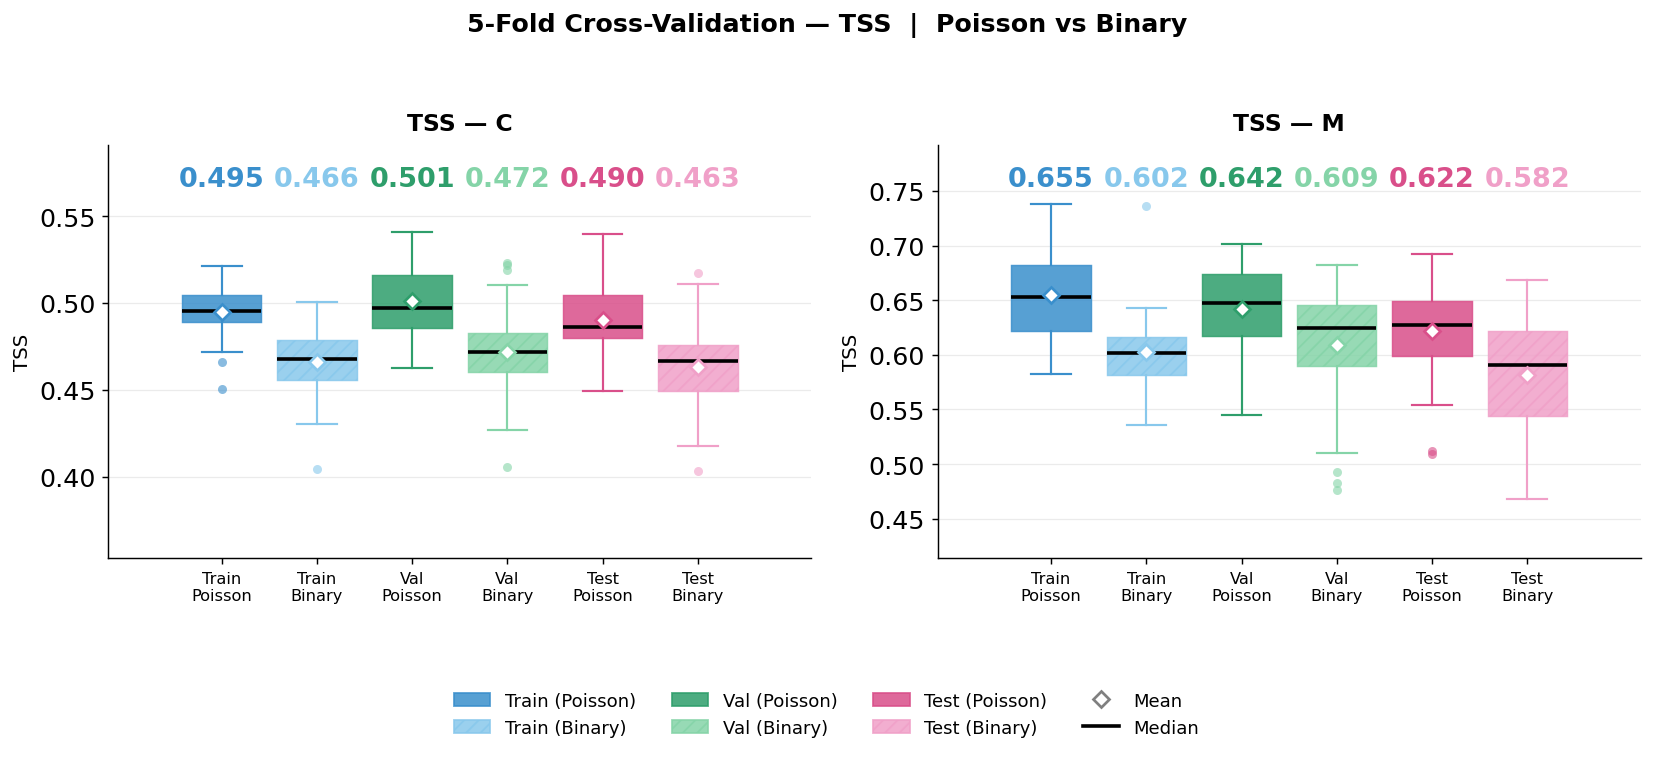

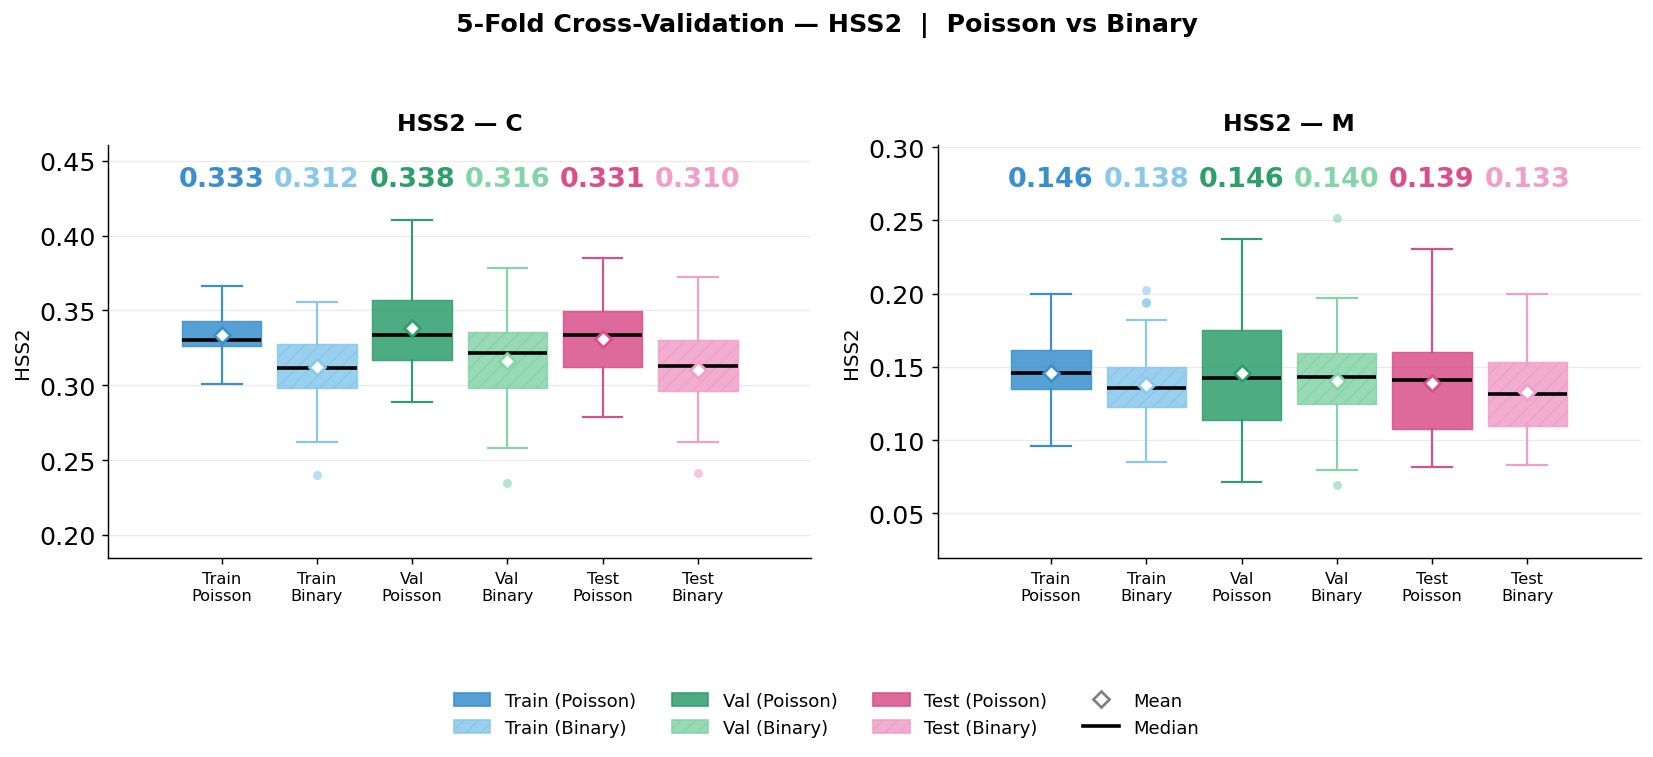

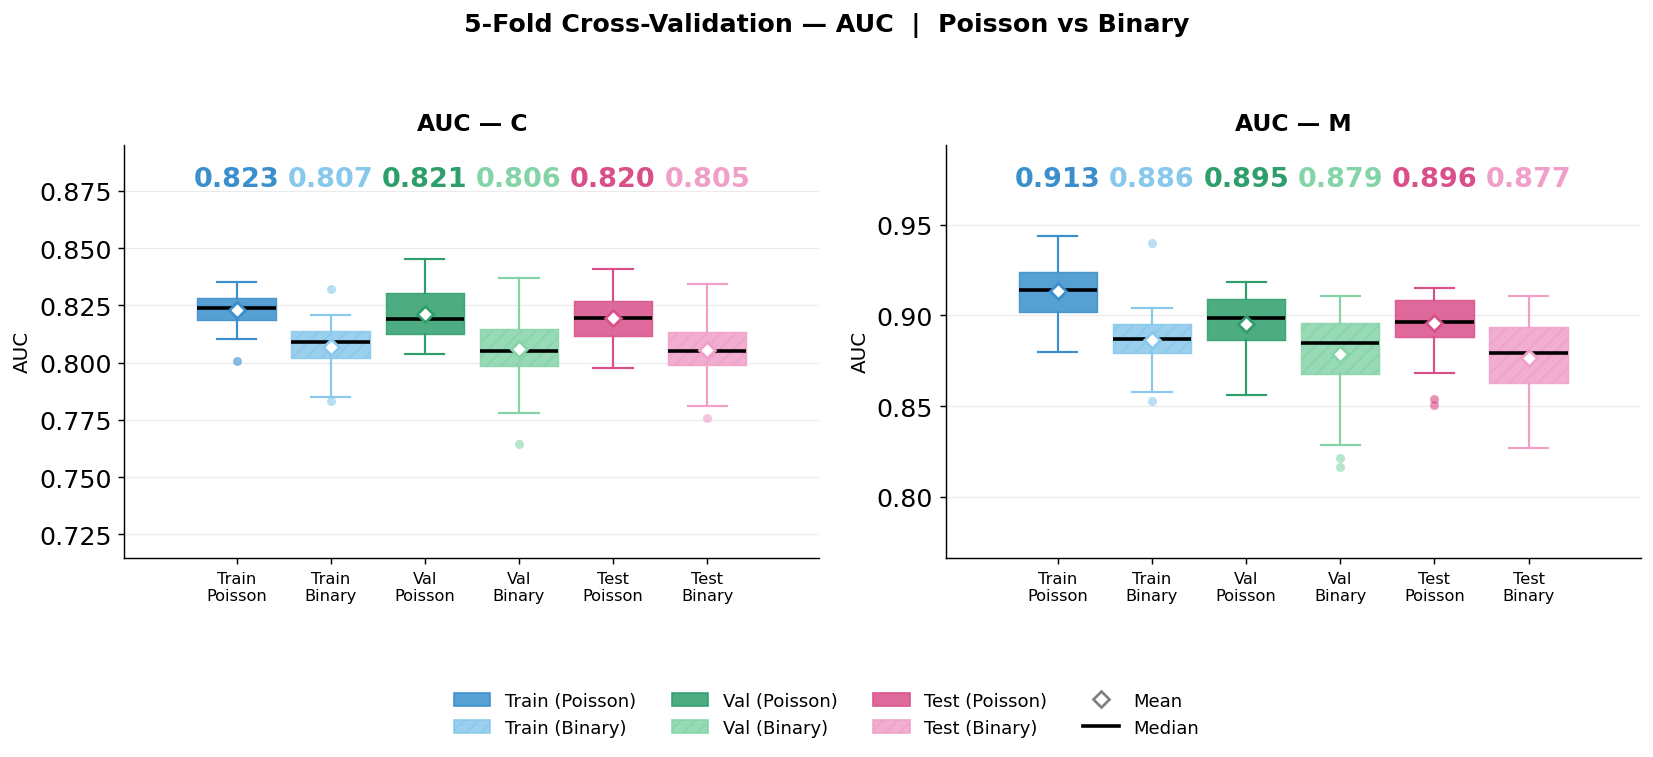

In [29]:
METRICS = ['TSS', 'HSS2', 'AUC']
CLASSES = ['C', 'M']  # add 'X' if the {split}_HSS2_X / {split}_AUC_X columns exist

SPLIT_MODE_STYLES = {
    ('train', 'poisson'): {'color': '#3A8FCC', 'hatch': ''},
    ('train', 'binary'):  {'color': '#88C8EC', 'hatch': '///'},
    ('val',   'poisson'): {'color': '#2E9E6B', 'hatch': ''},
    ('val',   'binary'):  {'color': '#85D4A8', 'hatch': '///'},
    ('test',  'poisson'): {'color': '#D94F8A', 'hatch': ''},
    ('test',  'binary'):  {'color': '#F0A0C8', 'hatch': '///'},
}

BOX_WIDTH  = 0.35
SPLIT_GAP  = 0.42
mode_labels  = {'poisson': 'Poisson', 'binary': 'Binary'}
split_labels = {'train': 'Train', 'val': 'Val', 'test': 'Test'}

keys    = list(SPLIT_MODE_STYLES.keys())
n       = len(keys)
offsets = np.linspace(-(n - 1) * SPLIT_GAP / 2, (n - 1) * SPLIT_GAP / 2, n)

legend_handles = [
    mpatches.Patch(
        facecolor=style['color'], hatch=style['hatch'],
        alpha=0.85, edgecolor=style['color'],
        label=f'{split_labels[s]} ({mode_labels[m]})'
    )
    for (s, m), style in SPLIT_MODE_STYLES.items()
]
legend_handles.append(
    Line2D([0], [0], marker='D', color='gray',
           markerfacecolor='white', markeredgecolor='gray',
           markeredgewidth=1.5, markersize=6, linewidth=0, label='Mean')
)
legend_handles.append(Line2D([0], [0], color='black', linewidth=2, label='Median'))

for metric in METRICS:

    fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)

    for ax, cls in zip(axes, CLASSES):

        all_vals = []

        for ki, (split, mode) in enumerate(keys):
            col     = f'{split}_{metric}_{cls}'
            df_mode = metrics_df[metrics_df['mode'] == mode]
            if col not in df_mode.columns:
                continue
            vals = df_mode[col].dropna().values
            if len(vals) == 0:
                continue

            all_vals.extend(vals)
            style = SPLIT_MODE_STYLES[(split, mode)]
            pos   = offsets[ki]

            bp = ax.boxplot(
                vals,
                positions=[pos],
                widths=BOX_WIDTH,
                patch_artist=True,
                notch=False,
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(linewidth=1.2, color=style['color']),
                capprops=dict(linewidth=1.2,    color=style['color']),
                flierprops=dict(marker='o', markersize=5,
                                markerfacecolor=style['color'],
                                alpha=0.6, markeredgewidth=0),
                boxprops=dict(linewidth=0.8, edgecolor=style['color']),
            )
            box = bp['boxes'][0]
            box.set_facecolor(style['color'])
            box.set_alpha(0.85)
            box.set_hatch(style['hatch'])

            ax.plot(pos, np.mean(vals), marker='D', color='white',
                    markeredgecolor=style['color'], markeredgewidth=1.5,
                    markersize=6, zorder=5)

            mean_val = np.mean(vals)
            ax.text(
                pos, 0.95, f'{mean_val:.3f}',
                transform=ax.get_xaxis_transform(),
                ha='center', va='top', fontsize=15,
                color=style['color'], fontweight='bold'
            )

        if all_vals:
            lo, hi  = np.min(all_vals), np.max(all_vals)
            margin  = max((hi - lo) * 0.20, 0.05)
            ax.set_ylim(lo - margin, hi + margin)

        ax.set_xticks(offsets)
        ax.set_xticklabels(
            [f'{split_labels[s]}\n{mode_labels[m]}' for s, m in keys],
            fontsize=9
        )
        ax.axhline(0, color='#aaaaaa', linestyle='--', linewidth=0.8)
        ax.set_title(f'{metric} — {cls}', fontsize=13, fontweight='bold', pad=8)
        ax.set_ylabel(metric, fontsize=11)
        ax.grid(axis='y', alpha=0.25, linewidth=0.7)
        ax.spines[['top', 'right']].set_visible(False)

    fig.legend(handles=legend_handles, loc='lower center', ncol=4,
               fontsize=10, frameon=False, bbox_to_anchor=(0.5, -0.12))
    fig.suptitle(f'5-Fold Cross-Validation — {metric}  |  Poisson vs Binary',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.18)
    fig.savefig(os.path.join(OUTPUT_DIR, f'boxplot_{metric}_multiseed.png'),
                dpi=300, bbox_inches='tight')
    plt.show()

## 14. Paired comparison Poisson vs Binary — scatter, differences, bootstrap CI, raincloud

Comparison on the **same** seed×fold runs (paired via a merge on `seed`, `fold`), for a given metric × class × split. The panels are:

1. paired scatter plot Poisson vs Binary (one point per seed×fold run, 50 points in total);
2. distribution of the difference Δ = Poisson − Binary;
3. bootstrap confidence interval of the mean difference;
4. raincloud plot.

Figures are saved in `OUTPUT_DIR`. The final loop is restricted to `split='test'` and metric `TSS` to avoid generating dozens of figures; widen the lists to include train/val or the other metrics.

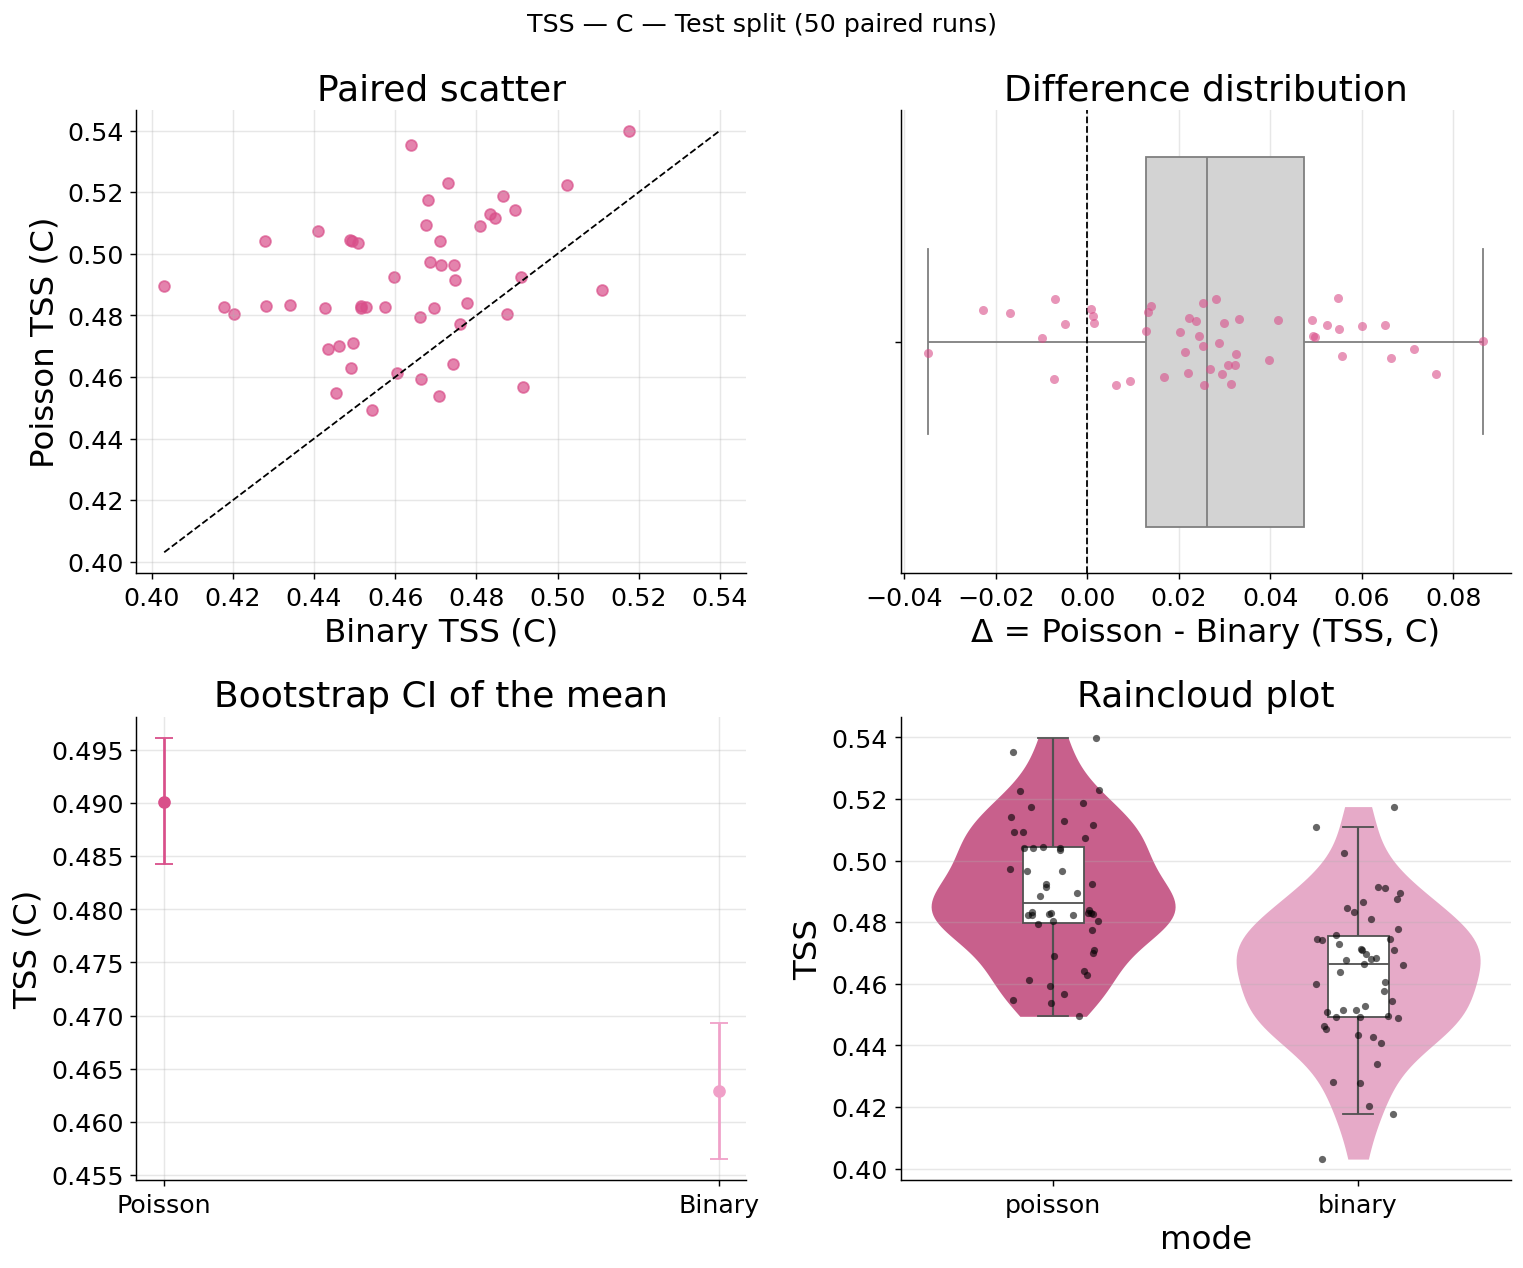

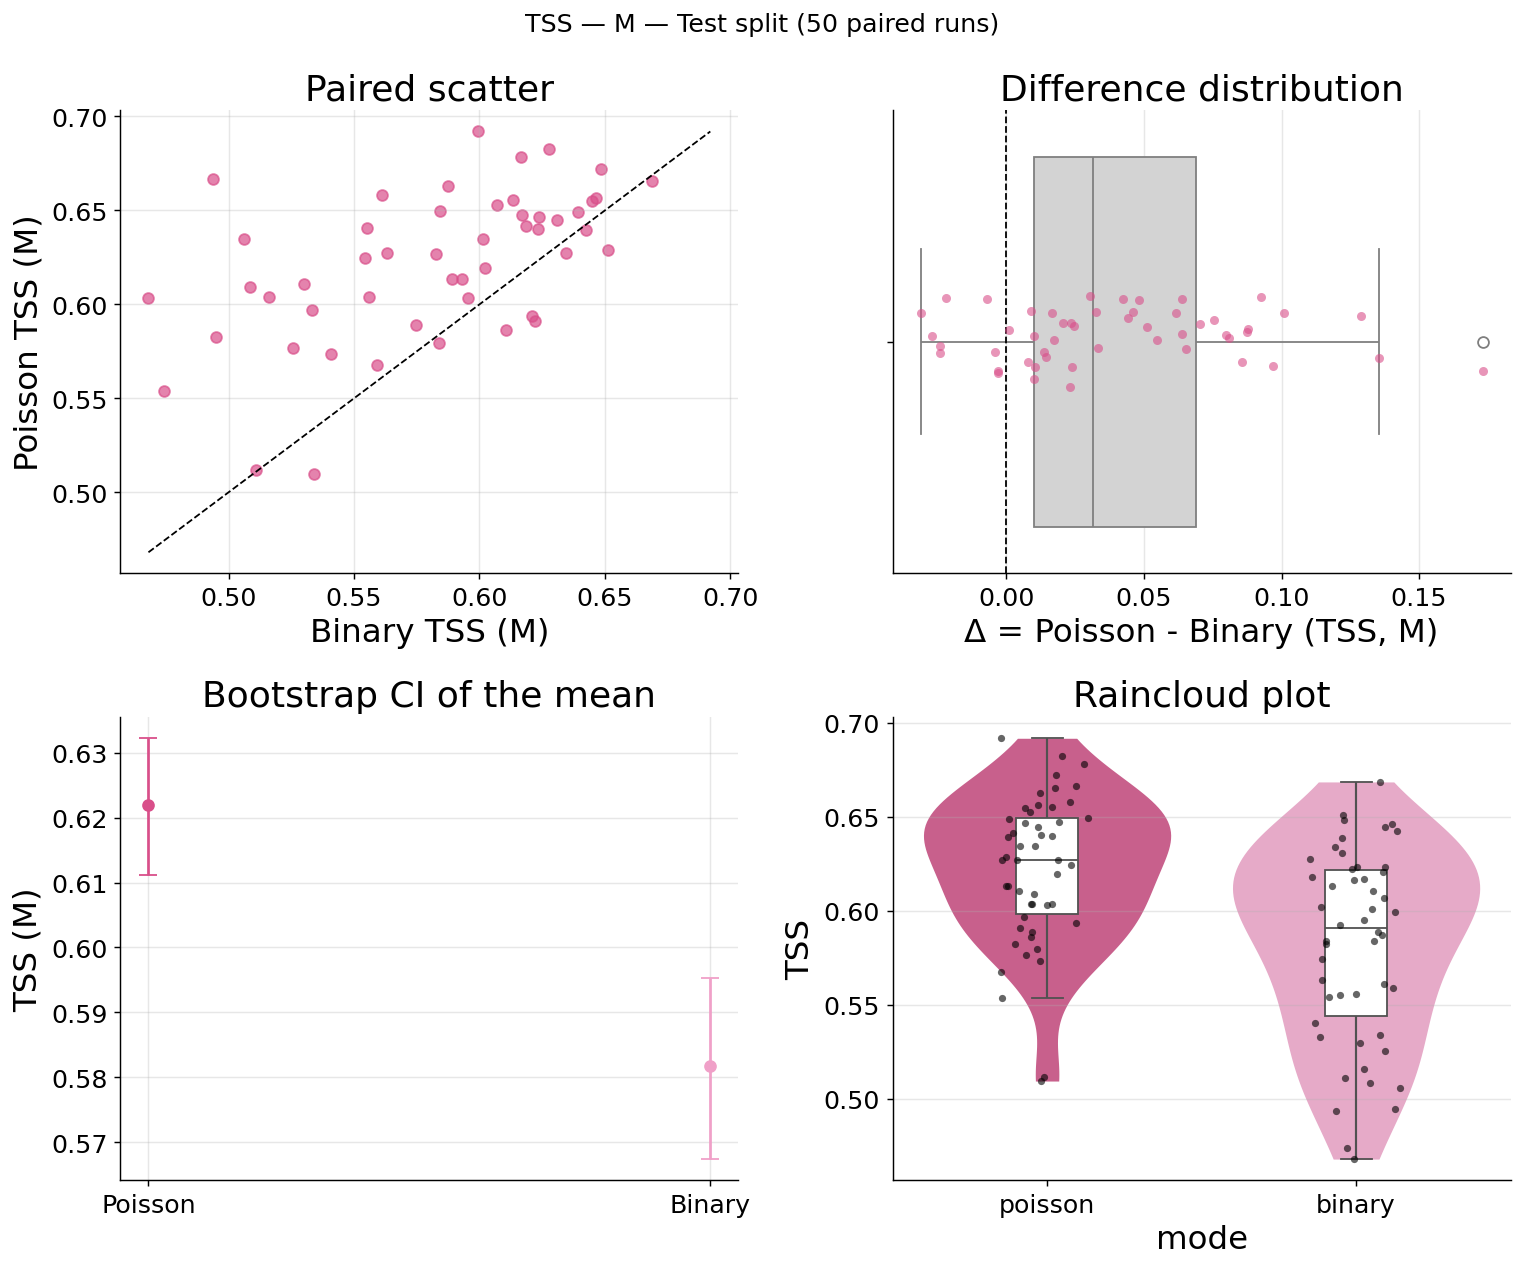

In [30]:
import seaborn as sns

def bootstrap_ci(data, n_boot=5000, ci=95):
    boot_means = []
    for _ in range(n_boot):
        sample = np.random.choice(data, size=len(data), replace=True)
        boot_means.append(sample.mean())
    alpha = (100 - ci) / 2
    return np.percentile(boot_means, [alpha, 100 - alpha])


def plot_all_for_class_and_split(metrics_df, cls='C', metric='TSS', split='test'):
    """
    Create a 2x2 figure for a given class, metric and split:
    (1) paired scatter Poisson vs Binary, (2) distribution of the differences,
    (3) bootstrap CI of the mean, (4) raincloud plot.
    Colours follow SPLIT_MODE_STYLES defined in the previous section.
    """

    col = f"{split}_{metric}_{cls}"

    df_p = metrics_df[metrics_df['mode'] == 'poisson'][['seed', 'fold', col]].rename(columns={col: 'poisson'})
    df_b = metrics_df[metrics_df['mode'] == 'binary'][['seed', 'fold', col]].rename(columns={col: 'binary'})
    merged = pd.merge(df_p, df_b, on=['seed', 'fold'], how='inner').dropna()

    long_df = merged.melt(
        id_vars=['seed', 'fold'],
        value_vars=['poisson', 'binary'],
        var_name='mode',
        value_name=metric
    )

    color_p = SPLIT_MODE_STYLES[(split, 'poisson')]['color']
    color_b = SPLIT_MODE_STYLES[(split, 'binary')]['color']

    vals_p = merged['poisson'].values
    vals_b = merged['binary'].values
    ci_p = bootstrap_ci(vals_p)
    ci_b = bootstrap_ci(vals_b)

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    ax1, ax2, ax3, ax4 = axes.flatten()

    # (1) Paired scatter — Poisson vs Binary
    ax1.scatter(merged['binary'], merged['poisson'], color=color_p, alpha=0.7)
    lims = [
        min(merged['binary'].min(), merged['poisson'].min()),
        max(merged['binary'].max(), merged['poisson'].max())
    ]
    ax1.plot(lims, lims, 'k--', linewidth=1)
    ax1.set_xlabel(f"Binary {metric} ({cls})")
    ax1.set_ylabel(f"Poisson {metric} ({cls})")
    ax1.set_title("Paired scatter")
    ax1.grid(alpha=0.3)

    # (2) Difference distribution
    merged['delta'] = merged['poisson'] - merged['binary']
    sns.boxplot(x=merged['delta'], color='lightgray', ax=ax2)
    sns.stripplot(x=merged['delta'], color=color_p, alpha=0.6, ax=ax2)
    ax2.axvline(0, color='black', linestyle='--', linewidth=1)
    ax2.set_xlabel(f"Δ = Poisson - Binary ({metric}, {cls})")
    ax2.set_title("Difference distribution")
    ax2.grid(axis='x', alpha=0.3)

    # (3) Bootstrap CI of the mean
    means = [vals_p.mean(), vals_b.mean()]
    cis = [ci_p, ci_b]
    labels = ['Poisson', 'Binary']
    colors = [color_p, color_b]
    for i, (m, ci, c) in enumerate(zip(means, cis, colors)):
        ax3.errorbar(i, m, yerr=[[m - ci[0]], [ci[1] - m]], fmt='o', color=c, capsize=5)
    ax3.set_xticks([0, 1])
    ax3.set_xticklabels(labels)
    ax3.set_ylabel(f"{metric} ({cls})")
    ax3.set_title("Bootstrap CI of the mean")
    ax3.grid(alpha=0.3)

    # (4) Raincloud plot
    sns.violinplot(
        data=long_df, x='mode', y=metric, inner=None, cut=0, linewidth=0, scale='width',
        palette={'poisson': color_p, 'binary': color_b}, ax=ax4
    )
    sns.boxplot(
        data=long_df, x='mode', y=metric, width=0.20, showcaps=True,
        boxprops={'facecolor': 'white', 'zorder': 3}, showfliers=False,
        whiskerprops={'linewidth': 1.2}, zorder=3, ax=ax4
    )
    sns.stripplot(
        data=long_df, x='mode', y=metric, color='black', size=4,
        jitter=0.15, alpha=0.6, zorder=4, ax=ax4
    )
    ax4.set_title("Raincloud plot")
    ax4.grid(axis='y', alpha=0.3)

    fig.suptitle(f"{metric} — {cls} — {split.capitalize()} split ({len(merged)} paired runs)", fontsize=14)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f'comparison_{metric}_{cls}_{split}.png'),
                dpi=300, bbox_inches='tight')
    plt.show()


# Default loop: test split / TSS / C and M only — extend the lists for more figures
for cls in ['C', 'M']:
    plot_all_for_class_and_split(metrics_df, cls=cls, metric='TSS', split='test')

## 15. Histogram of count errors — C, M, X

NB: the number of samples is more or less 50 times the avg number of elements per split (10 seeds x 5 folds)
══════════════════════════════════════════════════════════════════════
SPLIT = train   (n samples = 924700) (10 seeds x 5 folds)
══════════════════════════════════════════════════════════════════════
  Class C:  mean |err| = 0.673   median |err| = 0.0   max |err| = 20
    counts per bin (0, 1, 2, 3, 4+):  [600457, 88604, 197109, 30148, 8382]
  Class M:  mean |err| = 0.248   median |err| = 0.0   max |err| = 7
    counts per bin (0, 1, 2, 3, 4+):  [723160, 175425, 25320, 414, 381]
  Class X:  mean |err| = 0.103   median |err| = 0.0   max |err| = 2
    counts per bin (0, 1, 2, 3, 4+):  [829333, 95328, 39, 0, 0]



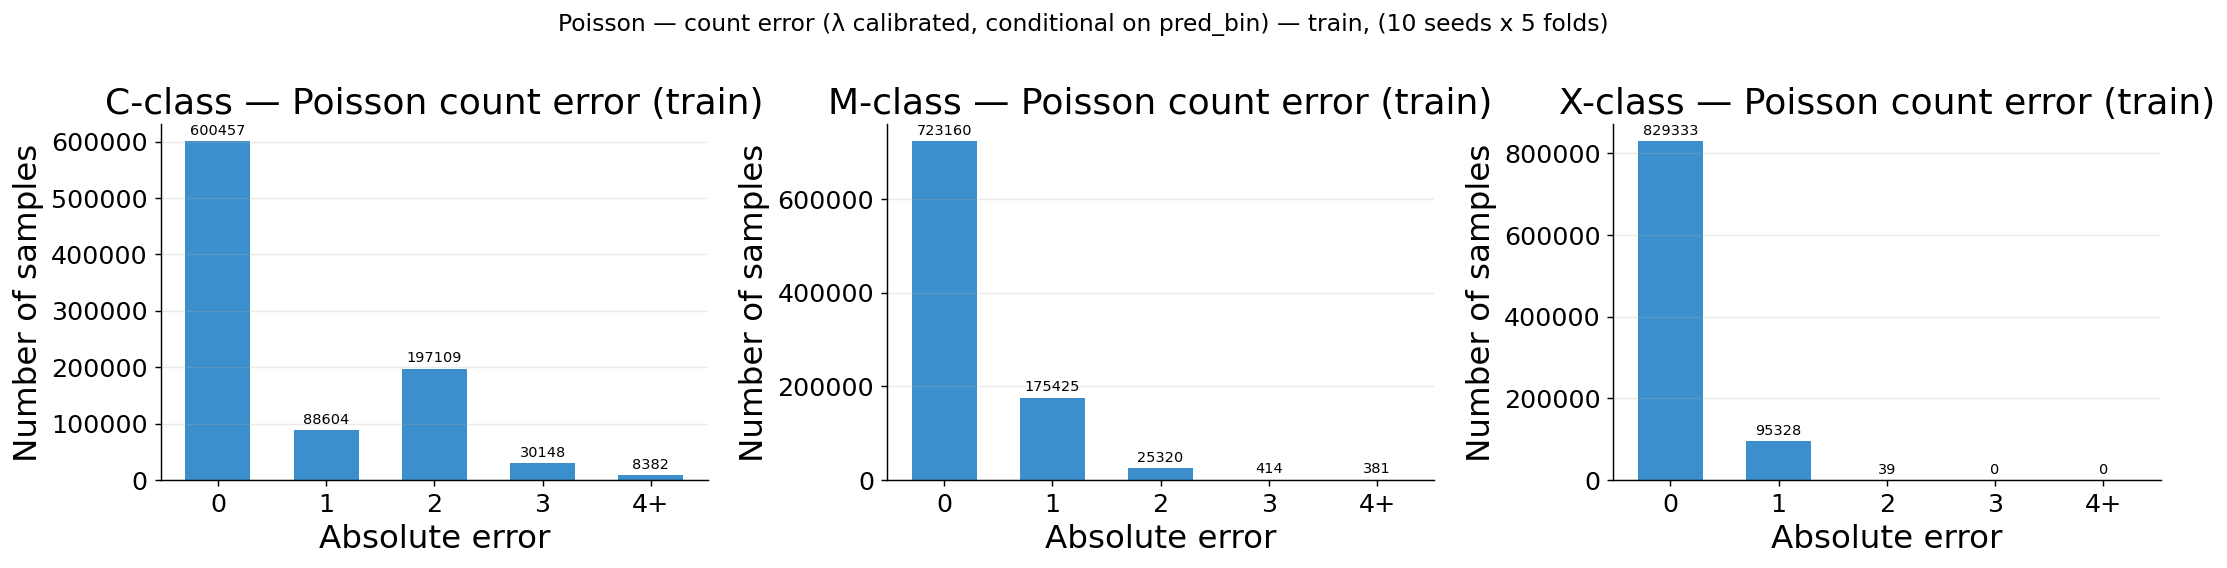

NB: the number of samples is more or less 50 times the avg number of elements per split (10 seeds x 5 folds)
══════════════════════════════════════════════════════════════════════
SPLIT = val   (n samples = 319330) (10 seeds x 5 folds)
══════════════════════════════════════════════════════════════════════
  Class C:  mean |err| = 0.675   median |err| = 0.0   max |err| = 20
    counts per bin (0, 1, 2, 3, 4+):  [207266, 30783, 67706, 10564, 3011]
  Class M:  mean |err| = 0.251   median |err| = 0.0   max |err| = 7
    counts per bin (0, 1, 2, 3, 4+):  [249134, 60707, 9151, 176, 162]
  Class X:  mean |err| = 0.104   median |err| = 0.0   max |err| = 2
    counts per bin (0, 1, 2, 3, 4+):  [286168, 33146, 16, 0, 0]



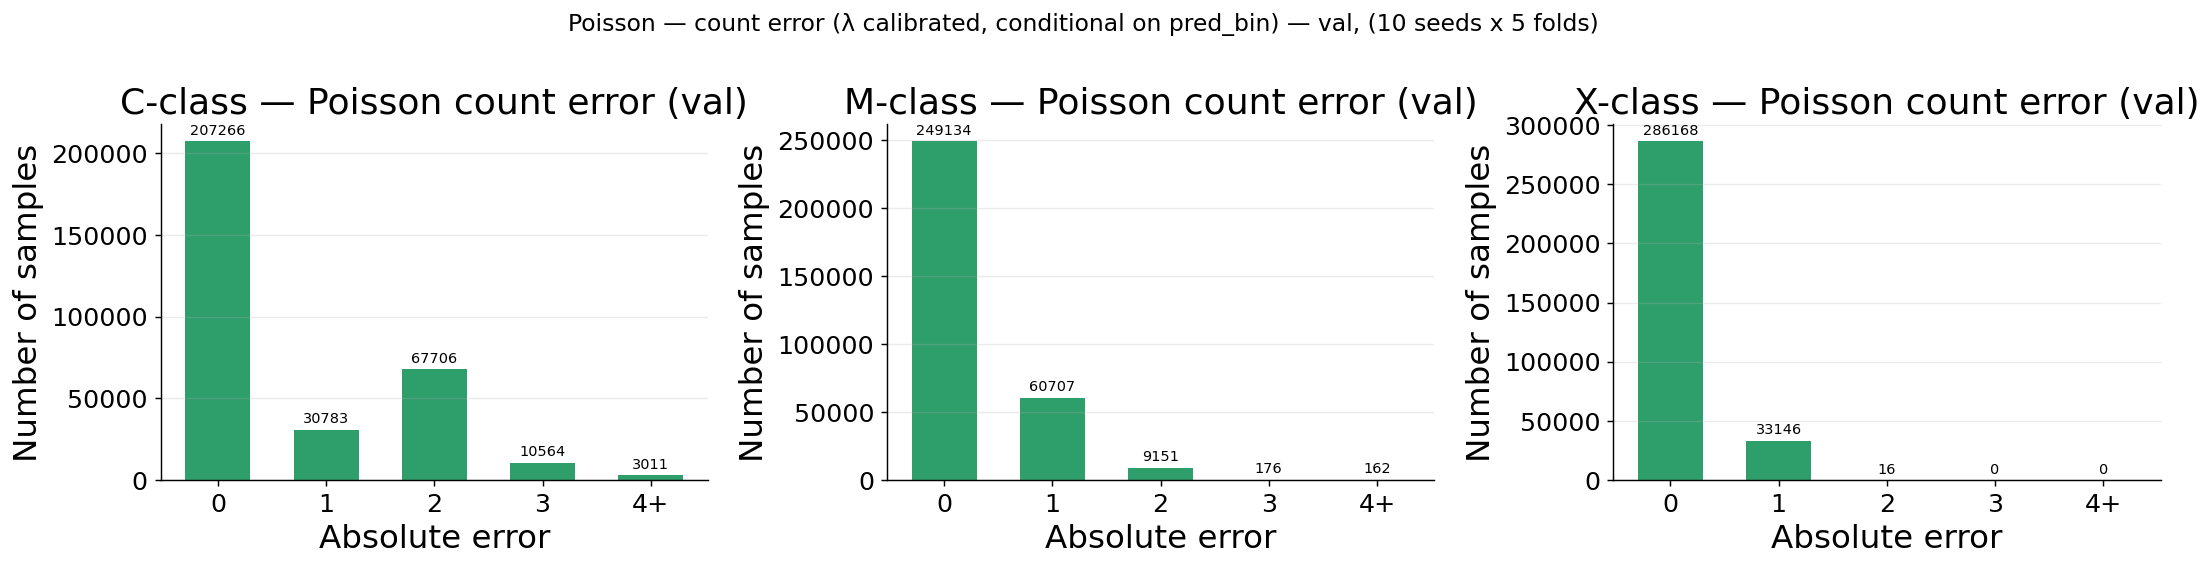

NB: the number of samples is more or less 50 times the avg number of elements per split (10 seeds x 5 folds)
══════════════════════════════════════════════════════════════════════
SPLIT = test   (n samples = 319330) (10 seeds x 5 folds)
══════════════════════════════════════════════════════════════════════
  Class C:  mean |err| = 0.678   median |err| = 0.0   max |err| = 20
    counts per bin (0, 1, 2, 3, 4+):  [206789, 30769, 68210, 10570, 2992]
  Class M:  mean |err| = 0.253   median |err| = 0.0   max |err| = 7
    counts per bin (0, 1, 2, 3, 4+):  [248646, 61169, 9167, 186, 162]
  Class X:  mean |err| = 0.103   median |err| = 0.0   max |err| = 3
    counts per bin (0, 1, 2, 3, 4+):  [286339, 32974, 15, 2, 0]



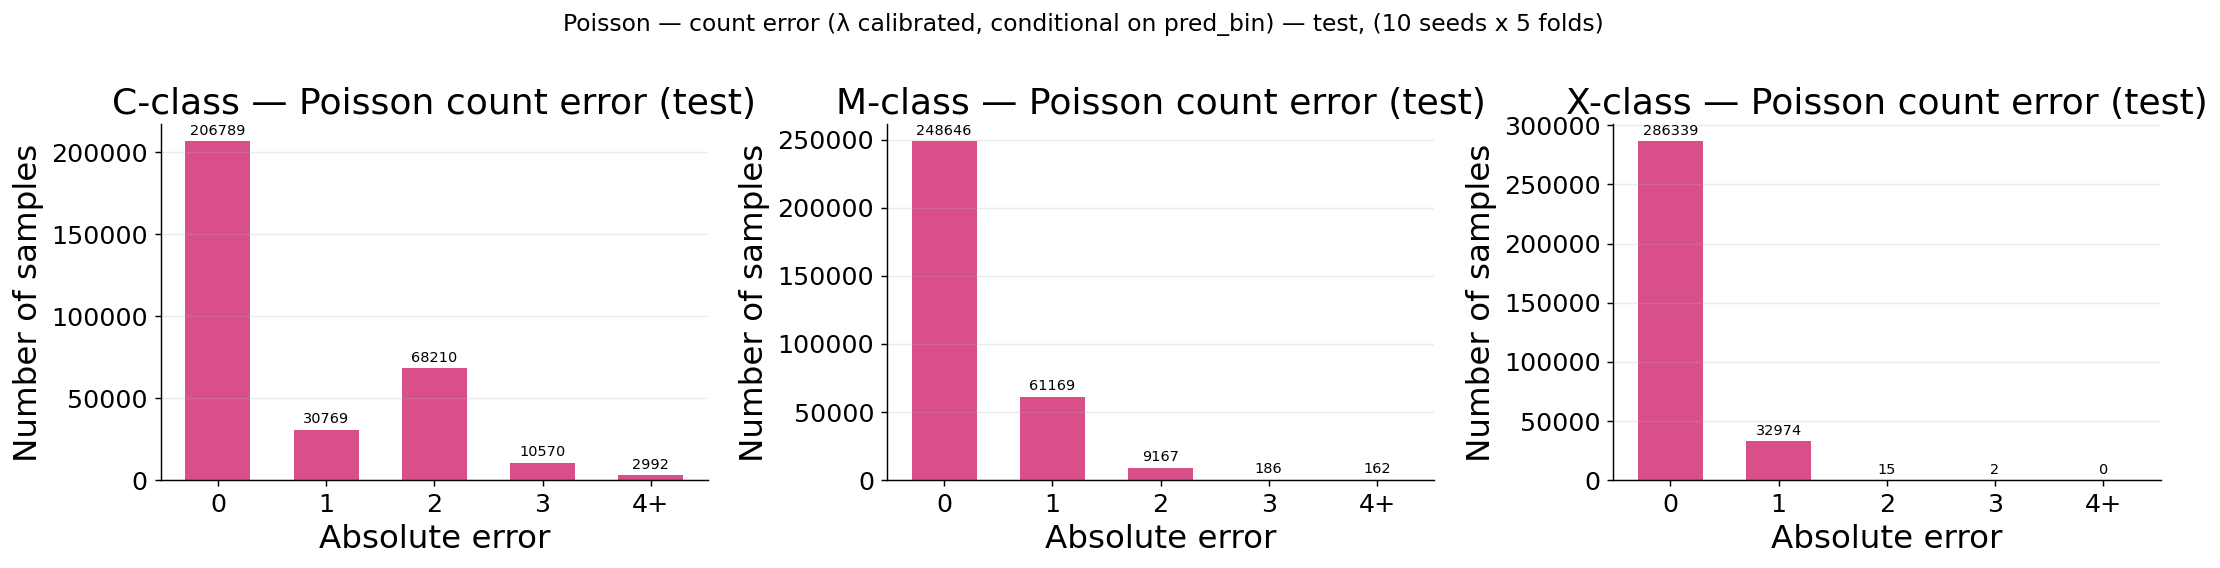

In [39]:
MAX_ERR_BIN  = 4  # errors >= this value are grouped in the last bar ("4+")

SPLIT_MODE_STYLES = {
    ('train', 'poisson'): {'color': '#3A8FCC', 'hatch': ''},
    ('train', 'binary'):  {'color': '#88C8EC', 'hatch': '///'},
    ('val',   'poisson'): {'color': '#2E9E6B', 'hatch': ''},
    ('val',   'binary'):  {'color': '#85D4A8', 'hatch': '///'},
    ('test',  'poisson'): {'color': '#D94F8A', 'hatch': ''},
    ('test',  'binary'):  {'color': '#F0A0C8', 'hatch': '///'},
}

bin_labels = [str(i) for i in range(MAX_ERR_BIN)] + [f'{MAX_ERR_BIN}+']

for ERR_SPLIT in ['train', 'val', 'test']:

    color_poi = SPLIT_MODE_STYLES[(ERR_SPLIT, 'poisson')]['color']
    sub = preds_df[(preds_df['split'] == ERR_SPLIT) & (preds_df['mode'] == 'poisson')].copy()

    print("NB: the number of samples is more or less 50 times the avg number of elements per split (10 seeds x 5 folds)")
    print("═"*70)
    print(f"SPLIT = {ERR_SPLIT}   (n samples = {len(sub)}) (10 seeds x 5 folds)")
    print("═"*70)

    fig, axes = plt.subplots(1, 3, figsize=(17, 4.5), sharey=False)

    for ax, cls in zip(axes, CLASS_NAMES):
        yt_true = sub[f'yt_{cls}'].round().astype(int)

        # Use the same calibrate() function defined in the lambda-calibration
        # section: it calibrates ONLY where pred_bin==1 and otherwise passes the
        # raw lambda through. This avoids forcing a value ~1 on all samples
        # (issue seen for class X, where the a,b fit relies on very few
        # positives and is almost degenerate).
        lam_raw   = sub[f'yp_{cls}'].values.astype(float)
        pred_bin  = sub[f'pred_bin_{cls}'].values
        lam_calib = calibrate(lam_raw, pred_bin, cls)
        pred_poi  = np.round(lam_calib).astype(int)

        err = np.abs(pred_poi - yt_true.values)
        err_c = pd.Series(err).clip(upper=MAX_ERR_BIN)
        counts = err_c.value_counts().reindex(range(MAX_ERR_BIN + 1), fill_value=0)

        print(f"  Class {cls}:  mean |err| = {err.mean():.3f}   median |err| = {np.median(err):.1f}   max |err| = {err.max()}")
        print(f"    counts per bin ({', '.join(bin_labels)}):  {counts.values.tolist()}")

        x = np.arange(len(bin_labels))
        bars = ax.bar(x, counts.values, width=0.6, color=color_poi)
        ax.bar_label(bars, fontsize=8, padding=2)

        ax.set_xticks(x)
        ax.set_xticklabels(bin_labels)
        ax.set_xlabel('Absolute error')
        ax.set_ylabel('Number of samples')
        ax.set_title(f'{cls}-class — Poisson count error ({ERR_SPLIT})')
        ax.grid(axis='y', alpha=0.25)

    print()
    fig.suptitle(f'Poisson — count error (λ calibrated, conditional on pred_bin) — {ERR_SPLIT}, (10 seeds x 5 folds) ', fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f'count_error_hist_poisson_{ERR_SPLIT}_total.png'),
                dpi=300, bbox_inches='tight')
    plt.show()

In [32]:
counts2 = (
    preds_df
    .groupby(['split', 'fold', 'seed', 'mode'])
    .size()
    .reset_index(name='n_rows')
)
print(counts2[(counts2['fold']==0) & (counts2['seed']==0)])

          split  fold  seed     mode  n_rows
0    pseudotest     0     0   binary     669
1    pseudotest     0     0  poisson     669
100        test     0     0   binary    6457
101        test     0     0  poisson    6457
200       train     0     0   binary   18572
201       train     0     0  poisson   18572
300         val     0     0   binary    6235
301         val     0     0  poisson    6235


## 16. Distribution of the TSS across runs — Poisson vs Binary

x-axis = TSS value, y-axis = number of runs (seed×fold) obtaining that TSS, shown separately for Poisson and Binary, for each split. Uses `metrics_df` (50 runs per mode).

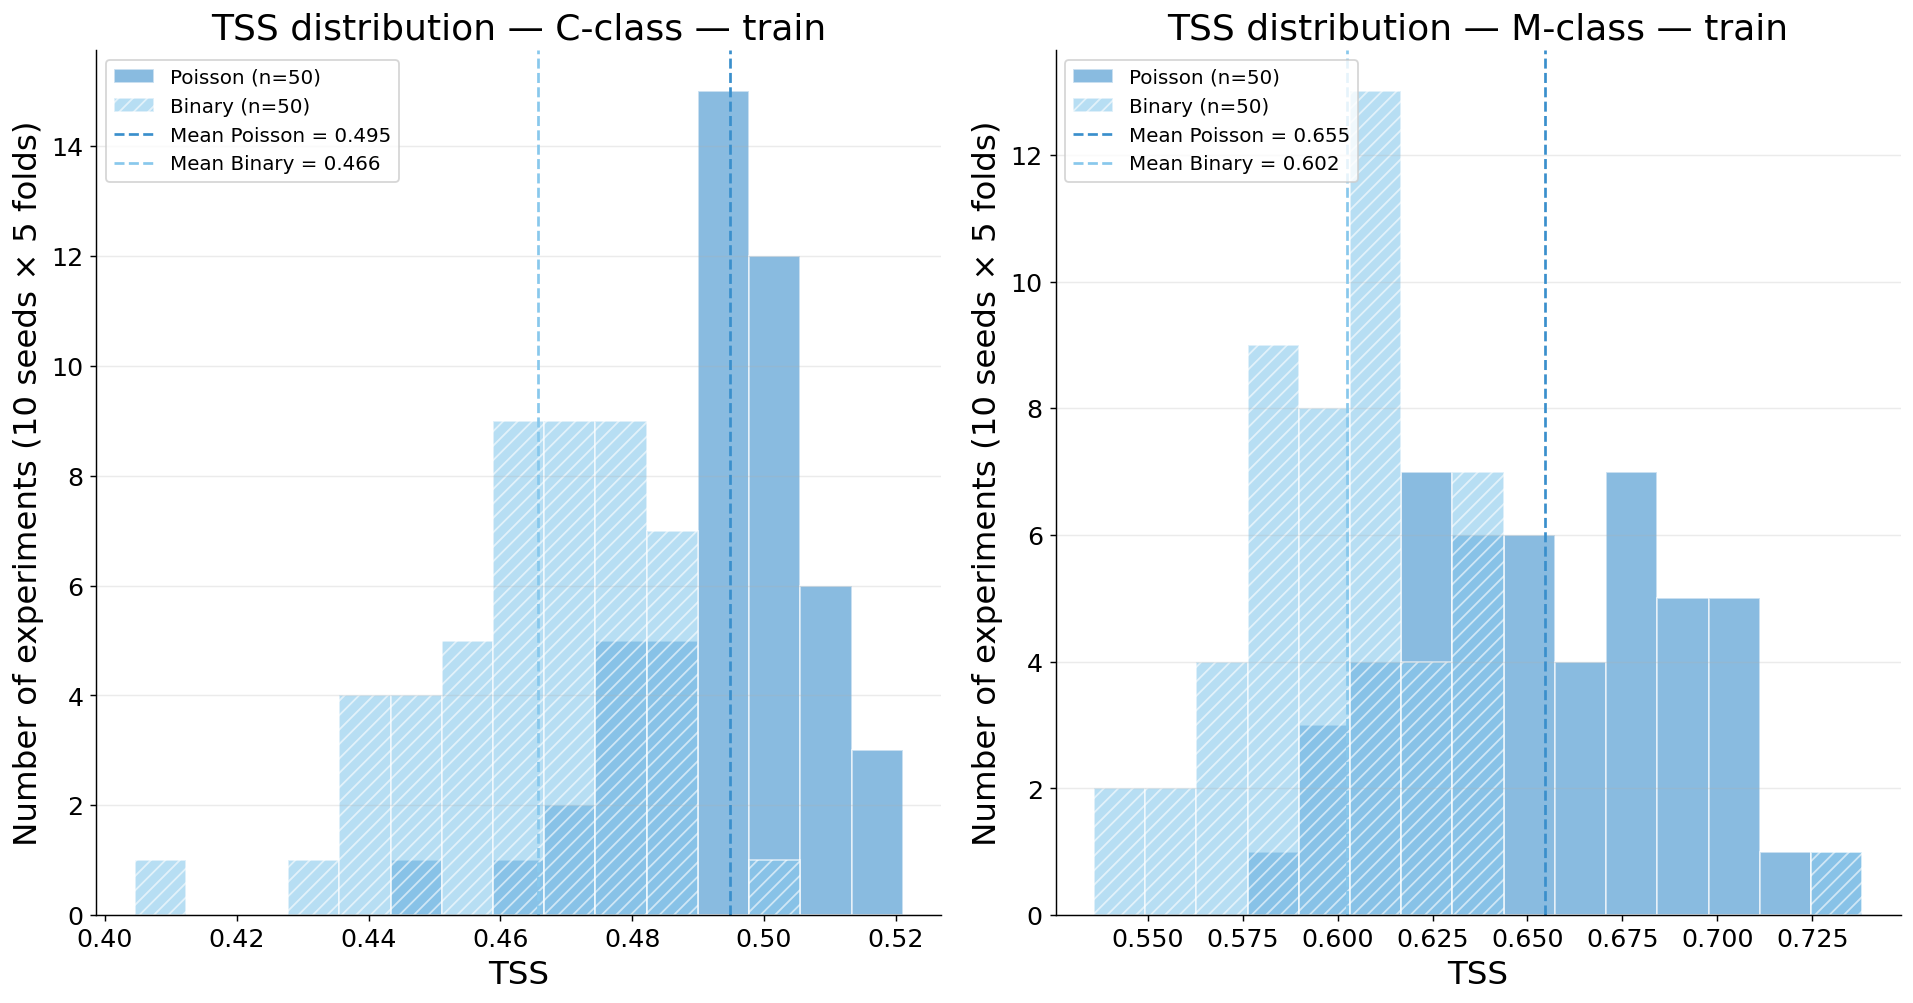

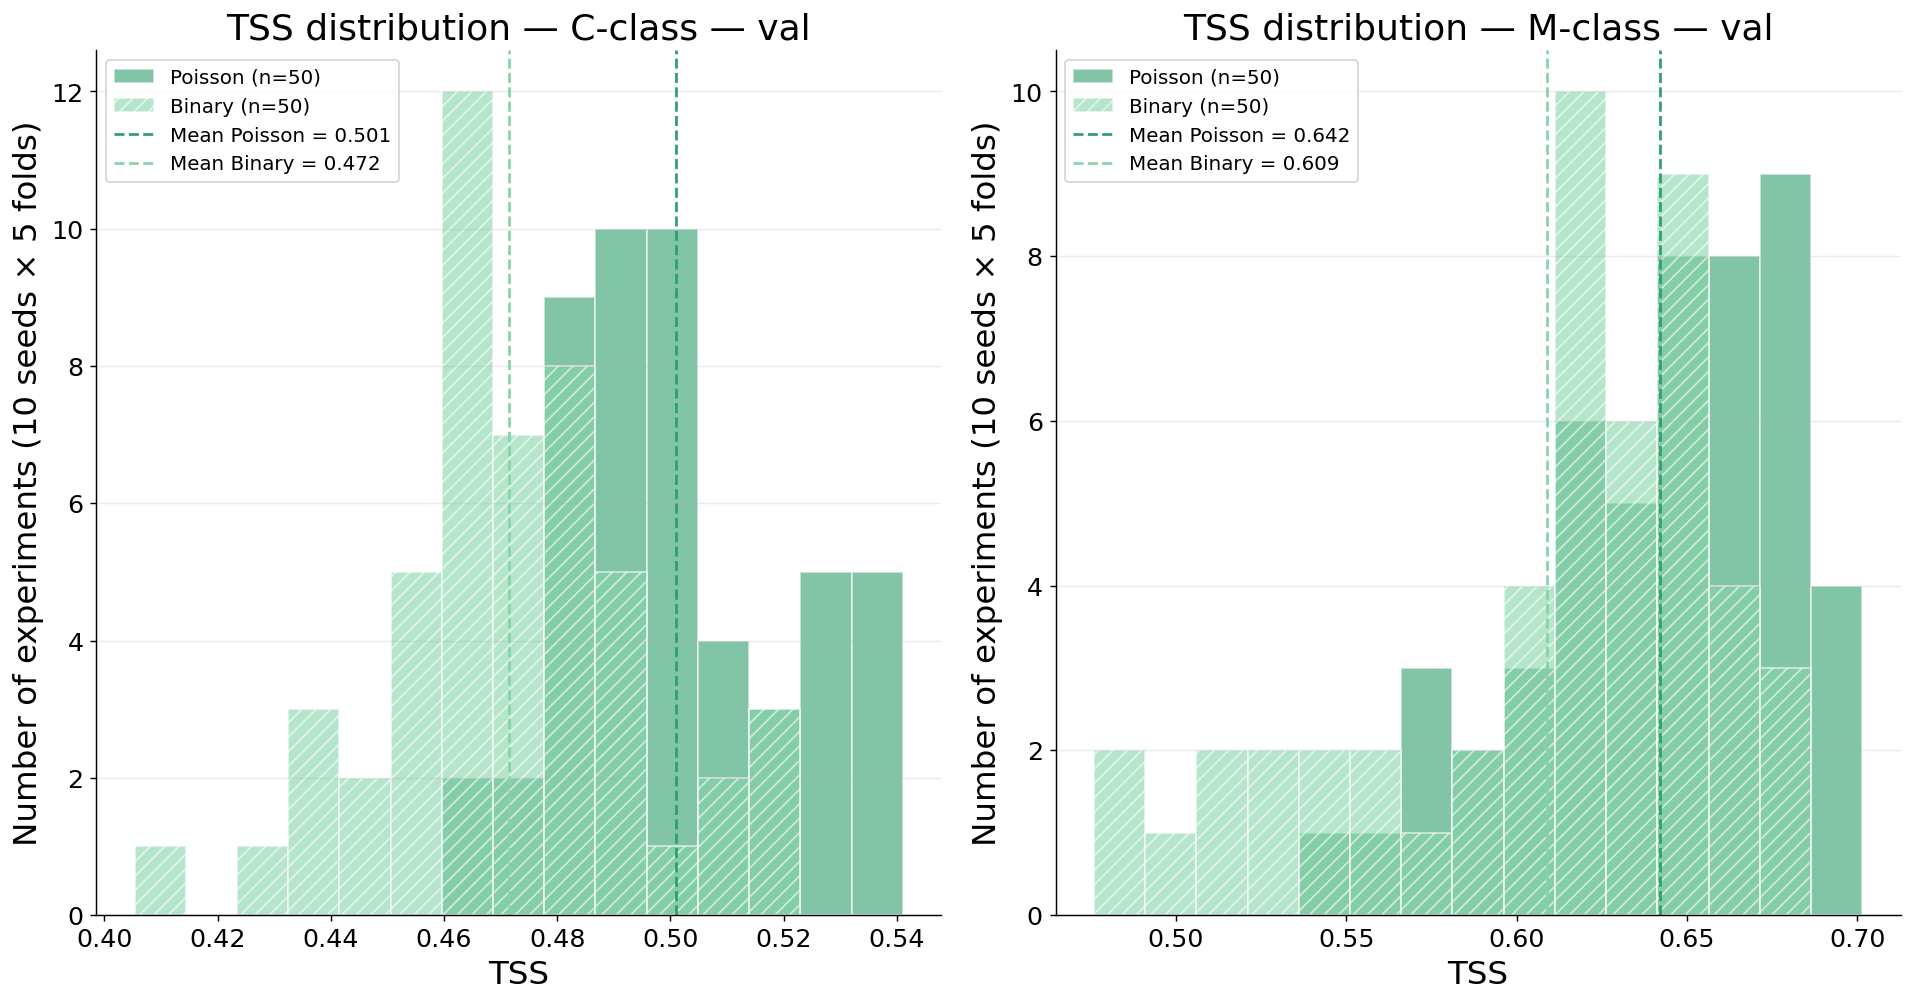

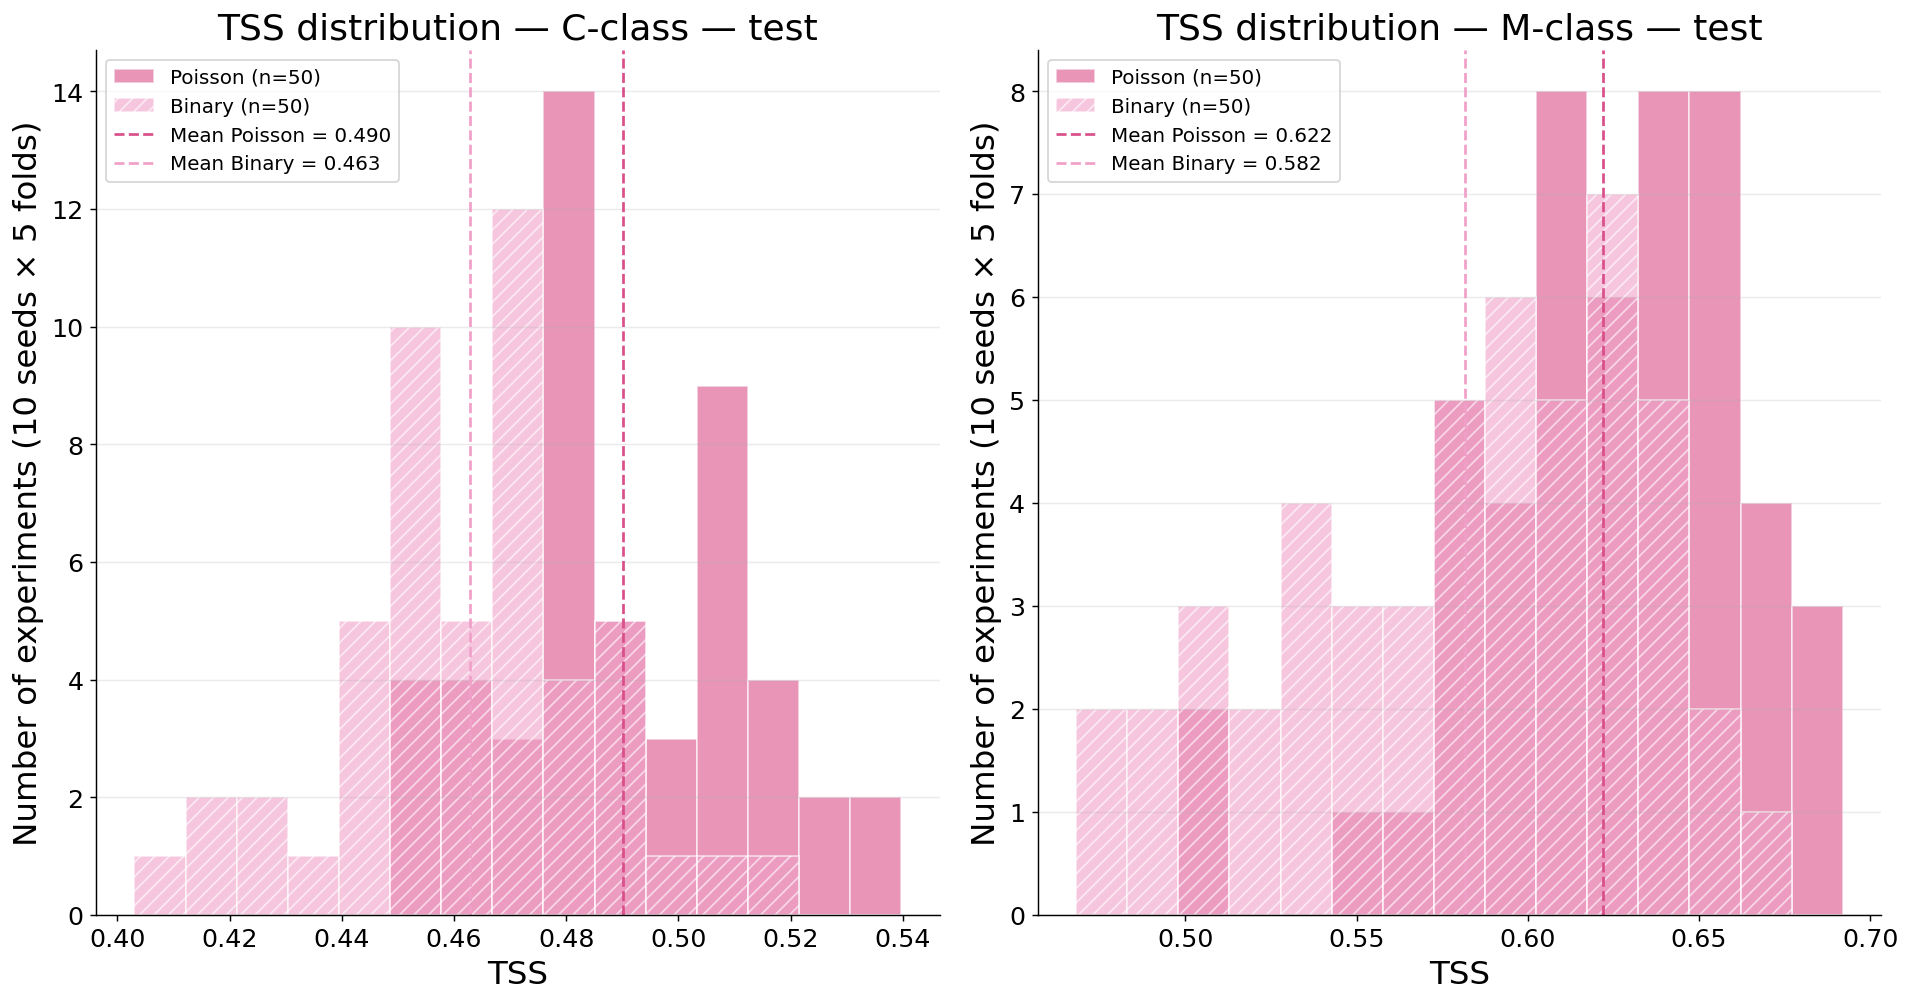

In [42]:
from matplotlib.lines import Line2D

N_BINS = 15

SPLIT_MODE_STYLES = {
    ('train', 'poisson'): {'color': '#3A8FCC', 'hatch': ''},
    ('train', 'binary'):  {'color': '#88C8EC', 'hatch': '///'},
    ('val',   'poisson'): {'color': '#2E9E6B', 'hatch': ''},
    ('val',   'binary'):  {'color': '#85D4A8', 'hatch': '///'},
    ('test',  'poisson'): {'color': '#D94F8A', 'hatch': ''},
    ('test',  'binary'):  {'color': '#F0A0C8', 'hatch': '///'},
}

for TSS_SPLIT in ['train', 'val', 'test']:

    color_poi = SPLIT_MODE_STYLES[(TSS_SPLIT, 'poisson')]['color']
    color_bin = SPLIT_MODE_STYLES[(TSS_SPLIT, 'binary')]['color']
    hatch_bin = SPLIT_MODE_STYLES[(TSS_SPLIT, 'binary')]['hatch']

    fig, axes = plt.subplots(1, 2, figsize=(15, 8), sharey=False)

    for ax, cls in zip(axes, ['C', 'M']):  # add 'X' if {split}_TSS_X exists
        col = f'{TSS_SPLIT}_TSS_{cls}'
        poi_vals = metrics_df.loc[metrics_df['mode'] == 'poisson', col].dropna().values
        bin_vals = metrics_df.loc[metrics_df['mode'] == 'binary', col].dropna().values

        all_vals  = np.concatenate([poi_vals, bin_vals])
        bin_edges = np.linspace(all_vals.min(), all_vals.max(), N_BINS + 1)

        ax.hist(poi_vals, bins=bin_edges, alpha=0.6, color=color_poi,
                edgecolor='white', label=f'Poisson (n={len(poi_vals)})')
        ax.hist(bin_vals, bins=bin_edges, alpha=0.6, color=color_bin,
                edgecolor='white', hatch=hatch_bin, label=f'Binary (n={len(bin_vals)})')

        poi_mean = poi_vals.mean()
        bin_mean = bin_vals.mean()
        ax.axvline(poi_mean, color=color_poi, linestyle='--', linewidth=1.5)
        ax.axvline(bin_mean, color=color_bin, linestyle='--', linewidth=1.5)

        ax.set_xlabel('TSS')
        ax.set_ylabel('Number of experiments (10 seeds × 5 folds)')
        ax.set_title(f'TSS distribution — {cls}-class — {TSS_SPLIT}')
        ax.grid(axis='y', alpha=0.25)

        legend_handles = [
            mpatches.Patch(facecolor=color_poi, alpha=0.6, edgecolor='white',
                           label=f'Poisson (n={len(poi_vals)})'),
            mpatches.Patch(facecolor=color_bin, alpha=0.6, edgecolor='white', hatch=hatch_bin,
                           label=f'Binary (n={len(bin_vals)})'),
            Line2D([0], [0], color=color_poi, linestyle='--', linewidth=1.5,
                   label=f'Mean Poisson = {poi_mean:.3f}'),
            Line2D([0], [0], color=color_bin, linestyle='--', linewidth=1.5,
                   label=f'Mean Binary = {bin_mean:.3f}'),
        ]
        ax.legend(handles=legend_handles, fontsize=11, loc='upper left')

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f'tss_distribution_hist_{TSS_SPLIT}.png'),
                dpi=300, bbox_inches='tight')
    plt.show()

## 17. Dataset overview

In [34]:
print("═"*70)
print("DATASET OVERVIEW — regression_number_24h_complete_timing.csv")
print("═"*70)

n_samples = len(timing_df)
print(f"Total samples (rows):        {n_samples}")

if 'ar_number' in timing_df.columns:
    n_ar = timing_df['ar_number'].nunique()
    print(f"Unique Active Regions (AR):  {n_ar}")

if 'sample_time' in timing_df.columns:
    st = pd.to_datetime(timing_df['sample_time'])
    print(f"Date range:                  {st.min()}  →  {st.max()}")

print()
print("─"*70)
print("Flare occurrence per class (within the window)")
print("─"*70)
print(f"{'Class':<8}{'n samples w/ flare':>22}{'% of dataset':>16}{'tot. flare events (more than 1 for some samples)':>20}")
for cls in CLASS_NAMES:
    col = f'{cls}_hours_list'
    if col not in timing_df.columns:
        print(f"  (colonna '{col}' non trovata — salto la classe {cls})")
        continue
    n_events_per_sample = timing_df[col].apply(len)
    has_flare = n_events_per_sample > 0
    n_pos     = has_flare.sum()
    n_events  = n_events_per_sample.sum()
    print(f"{cls:<8}{n_pos:>22}{100*n_pos/n_samples:>15.1f}%{n_events:>20}")

print()
print("─"*70)
print("Train / Val / Test split sizes  (da preds_df, media ± std su tutti i seed×fold)")
print("─"*70)

# Deduplicate on 'binary' so the same split is not counted twice (poisson and
# binary share the identical train/val/test partition)
split_sizes = (
    preds_df[preds_df['mode'] == 'binary']
    .groupby(['seed', 'fold', 'split'])['filename']
    .nunique()
    .reset_index(name='n')
)

summary = split_sizes.groupby('split')['n'].agg(['mean', 'std', 'min', 'max'])
print(summary.round(1).to_string())

n_runs = split_sizes.groupby(['seed', 'fold']).ngroups
print(f"\n(calcolato su {n_runs} combinazioni seed×fold)")

# Sanity check: for a single seed×fold combination, the sum of the three splits
# should be close to the total number of samples in the original dataset
one_run = split_sizes[(split_sizes['seed'] == split_sizes['seed'].iloc[0]) &
                       (split_sizes['fold'] == split_sizes['fold'].iloc[0])]
print(f"\nEsempio (seed={one_run['seed'].iloc[0]}, fold={one_run['fold'].iloc[0]}):")
print(one_run[['split', 'n']].to_string(index=False))
print(f"Somma train+val+test = {one_run['n'].sum()}  vs  totale dataset = {n_samples}")

══════════════════════════════════════════════════════════════════════
DATASET OVERVIEW — regression_number_24h_complete_timing.csv
══════════════════════════════════════════════════════════════════════
Total samples (rows):        31933
Unique Active Regions (AR):  4976
Date range:                  1996-06-27 00:01:30  →  2022-12-30 23:58:29

──────────────────────────────────────────────────────────────────────
Flare occurrence per class (within the window)
──────────────────────────────────────────────────────────────────────
Class       n samples w/ flare    % of datasettot. flare events (more than 1 for some samples)
C                         4801           15.0%               10145
M                          853            2.7%                1261
X                          107            0.3%                 118

──────────────────────────────────────────────────────────────────────
Train / Val / Test split sizes  (da preds_df, media ± std su tutti i seed×fold)
─────────────────

In [35]:
# Compute the counts for each class
timing_df['C_count'] = timing_df['C_hours_list'].apply(len)
timing_df['M_count'] = timing_df['M_hours_list'].apply(len)
timing_df['X_count'] = timing_df['X_hours_list'].apply(len)

# Group by configuration (C_count, M_count, X_count)
combo_counts = (
    timing_df
    .groupby(['C_count', 'M_count', 'X_count'])
    .size()
    .reset_index(name='n_samples')
    .sort_values('n_samples', ascending=False)
)

# Percentage of the total
total = len(timing_df)
combo_counts['percentage'] = 100 * combo_counts['n_samples'] / total

# Print the most frequent configurations
print(combo_counts.head(10).to_string(index=False))


 C_count  M_count  X_count  n_samples  percentage
       0        0        0      26866   84.132402
       1        0        0       2558    8.010522
       2        0        0        818    2.561613
       3        0        0        336    1.052203
       0        1        0        218    0.682679
       4        0        0        183    0.573075
       1        1        0        136    0.425892
       5        0        0        110    0.344471
       2        1        0         78    0.244261
       6        0        0         59    0.184762


## 18. Derived cumulative C+ / M+ metrics

In [38]:
# ══════════════════════════════════════════════════════════════
# DERIVED CUMULATIVE C+ / M+ METRICS (for comparison with literature)
# ══════════════════════════════════════════════════════════════
# C+ : at least one flare of class C or above (C, M, or X)
# M+ : at least one flare of class M or above (M or X)
#
# These are NOT directly optimised targets — they are aggregated from
# the three per-class heads under a conditional-independence assumption.

CUM_DEFS = {
    'C+': ['C', 'M', 'X'],
    'M+': ['M', 'X'],
}

# --- 1. Ground truth: exact (no independence assumption needed) ---
for cum_cls, members in CUM_DEFS.items():
    preds_df[f'true_bin_{cum_cls}'] = preds_df[[f'true_bin_{c}' for c in members]].max(axis=1)

# --- 2. Aggregated scores ---
# Binary model: p(at least one class in `members`) via OR of independent events
# Poisson model: sum of rates -> lambda of the aggregated Poisson process
for cum_cls, members in CUM_DEFS.items():
    poi_mask = preds_df['mode'] == 'poisson'
    bin_mask = preds_df['mode'] == 'binary'

    # Poisson: sum of independent Poisson rates is itself Poisson(sum of lambdas)
    preds_df.loc[poi_mask, f'yp_{cum_cls}'] = (
        preds_df.loc[poi_mask, [f'yp_{c}' for c in members]].sum(axis=1)
    )

    # Binary: P(at least one) = 1 - prod(1 - p_k), assuming conditional independence
    one_minus_p = 1.0
    for c in members:
        one_minus_p = one_minus_p * (1 - preds_df.loc[bin_mask, f'yp_{c}'])
    preds_df.loc[bin_mask, f'yp_{cum_cls}'] = 1 - one_minus_p

# --- 3. Re-calibrate tau on val split for the two derived scores ---
tau_cum_records = []
groups = preds_df[preds_df['split'] == 'val'].groupby(['seed', 'fold', 'mode'])
for (seed, fold, mode), sub in groups:
    row = {'seed': seed, 'fold': fold, 'mode': mode}
    for cum_cls in CUM_DEFS:
        yt = sub[f'true_bin_{cum_cls}'].values
        yp = sub[f'yp_{cum_cls}'].values
        if mode == 'poisson':
            taus = np.linspace(TAU_MIN, min(TAU_MAX, float(np.percentile(yp, 99)) + 0.1), N_TAU)
        else:
            taus = np.linspace(0.01, 0.99, N_TAU)
        tss_vals = [confusion_skills(yt.astype(int), (yp >= t).astype(int))['TSS'] for t in taus]
        row[f'tau_{cum_cls}'] = float(taus[np.argmax(tss_vals)])
    tau_cum_records.append(row)

tau_cum_df = pd.DataFrame(tau_cum_records)
preds_df = preds_df.merge(tau_cum_df, on=['seed', 'fold', 'mode'], how='left')

for cum_cls in CUM_DEFS:
    preds_df[f'pred_bin_{cum_cls}'] = (preds_df[f'yp_{cum_cls}'] >= preds_df[f'tau_{cum_cls}']).astype(int)

# --- 4. Metrics per run, per split ---
cum_records = []
for split in ['train', 'val', 'test']:
    sub_split = preds_df[preds_df['split'] == split]
    for (seed, fold, mode), sub in sub_split.groupby(['seed', 'fold', 'mode']):
        for cum_cls in CUM_DEFS:
            yt = sub[f'true_bin_{cum_cls}'].values.astype(int)
            yp = sub[f'pred_bin_{cum_cls}'].values.astype(int)
            skills = confusion_skills(yt, yp)
            cum_records.append({
                'seed': seed, 'fold': fold, 'mode': mode, 'split': split,
                'class': cum_cls, 'TSS': skills['TSS'], 'HSS2': skills.get('HSS2', np.nan),
            })

cum_df = pd.DataFrame(cum_records)
summary_cum = cum_df.groupby(['mode', 'split', 'class'])[['TSS', 'HSS2']].agg(['mean', 'std']).round(4)
print(summary_cum.to_string())

                        TSS            HSS2        
                       mean     std    mean     std
mode    split class                                
binary  test  C+     0.4730  0.0252  0.3326  0.0299
              M+     0.5891  0.0512  0.1461  0.0318
        train C+     0.4771  0.0198  0.3351  0.0282
              M+     0.6122  0.0316  0.1518  0.0273
        val   C+     0.4816  0.0254  0.3387  0.0336
              M+     0.6143  0.0533  0.1535  0.0370
poisson test  C+     0.5010  0.0232  0.3512  0.0246
              M+     0.6316  0.0397  0.1586  0.0366
        train C+     0.5088  0.0137  0.3563  0.0189
              M+     0.6653  0.0380  0.1667  0.0309
        val   C+     0.5124  0.0219  0.3596  0.0278
              M+     0.6499  0.0383  0.1649  0.0435
